# 👥 Employee Attrition Predictor — People Analytics Masterclass

---

| | |
|---|---|
| **Author** | Dr Harry Patria |
| **Organisation** | Patria & Co. |
| **Dataset** | IBM HR Analytics Employee Attrition (1,470 records) |
| **Model** | Gradient Boosting Classifier + SHAP Explanations |
| **Purpose** | End-to-end People Analytics: EDA → Preprocessing → Modelling → Deployment |

---

## What You Will Learn

This notebook walks you through the **complete data science lifecycle** for a real HR analytics problem — predicting which employees are at risk of leaving. By the end, you will be able to:

1. Load and explore HR data
2. Clean and preprocess data for machine learning
3. Engineer meaningful features
4. Train and compare multiple models
5. Explain model predictions with SHAP values
6. Run "what-if" scenario simulations
7. Export a production-ready model and generate a full-stack app prompt

> **Beginner tip:** Every code block has a comment section below it explaining what it does. Read those if anything is unclear!

---

## Table of Contents

1. [Installation & Setup](#1)
2. [Import Libraries](#2)
3. [Load Data & Initial Exploration](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Data Preprocessing Pipeline](#5)
6. [Feature Engineering](#6)
7. [Model Training — Multiple Algorithms](#7)
8. [Cross-Validation & Model Selection](#8)
9. [SHAP Feature Importance](#9)
10. [Model Evaluation & Confusion Matrix](#10)
11. [Deployment Readiness Checklist](#11)
12. [Interactive Scenario Analytics Dashboard](#12)
13. [Save Artefacts for Production](#13)
14. [Vibe Coding Prompt — Generate Full-Stack App](#14)

<a id='1'></a>
## Section 1 — Installation & Setup

### Prerequisites

Before running this notebook for the first time, follow these steps:

#### Step 1 — Install Python
Download Python 3.11+ from [python.org](https://www.python.org/downloads/). Make sure to tick **"Add Python to PATH"** during installation.

#### Step 2 — Create a virtual environment (optional but recommended)
```bash
# Open your terminal / command prompt
python -m venv venv

# Activate it:
# Windows:
venv\Scripts\activate
# macOS / Linux:
source venv/bin/activate
```

#### Step 3 — Install Jupyter
```bash
pip install jupyter notebook
# Then launch:
jupyter notebook
```

#### Step 4 — Install all required libraries
Run the cell below (or paste the pip command into your terminal).

In [ ]:
# =============================================================================
# INSTALLATION CELL — Run this once when you first open the notebook
# The exclamation mark (!) lets us run terminal commands from inside Jupyter
# =============================================================================

!pip install pandas numpy scikit-learn matplotlib seaborn plotly shap joblib xgboost lightgbm imbalanced-learn ipywidgets -q

print("All libraries installed successfully!")

<a id='2'></a>
## Section 2 — Import Libraries

Here we import all the Python libraries we need. Think of libraries as toolboxes — each one gives us a specialised set of tools:

| Library | Purpose |
|---|---|
| `pandas` | Load, manipulate, and analyse tabular data |
| `numpy` | Fast numerical computations |
| `matplotlib / seaborn` | Static charts and plots |
| `plotly` | Interactive charts |
| `sklearn` | Machine learning algorithms and utilities |
| `shap` | Explain why a model made a particular prediction |
| `joblib` | Save and load trained models to/from disk |
| `xgboost / lightgbm` | Advanced gradient boosting algorithms |

In [1]:
# =============================================================================
# STANDARD LIBRARY IMPORTS
# =============================================================================
import warnings
import json
import os
from pathlib import Path
from io import StringIO

warnings.filterwarnings('ignore')  # Suppress non-critical warnings for cleaner output

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML, IFrame

# ── Machine learning — preprocessing ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Machine learning — algorithms ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# ── Machine learning — metrics ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

# ── SHAP — model explainability ───────────────────────────────────────────────
import shap
shap.initjs()  # Enable JavaScript renderer for SHAP plots inside Jupyter

# ── Serialisation ─────────────────────────────────────────────────────────────
import joblib

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("Libraries loaded. Python environment is ready!")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Sklearn : {__import__('sklearn').__version__}")
print(f"SHAP    : {shap.__version__}")

Libraries loaded. Python environment is ready!
Pandas  : 2.2.2
NumPy   : 2.0.2
Sklearn : 1.6.1
SHAP    : 0.51.0


**What happened above?**
- We imported every tool we'll need upfront so we don't get "NameError" surprises later
- `warnings.filterwarnings('ignore')` hides harmless deprecation messages
- `shap.initjs()` pre-loads SHAP's JavaScript renderer so interactive charts work inline
- `pd.set_option(...)` makes DataFrames display more columns without truncation

<a id='3'></a>
## Section 3 — Load Data & Initial Exploration

### About the Dataset
The **IBM HR Analytics Employee Attrition** dataset contains 1,470 employee records with 35 attributes. It was created by IBM data scientists to demonstrate people analytics. Each row is one employee; the target column `Attrition` tells us whether they left (`Yes`) or stayed (`No`).

### Where to get the data
Place the CSV at `data/01-raw/HR-Employee-Attrition.csv` relative to this notebook, or adjust the `DATA_PATH` variable below.

In [2]:
# =============================================================================
# GLOBAL CONFIGURATION — Edit these paths if your files are in different places
# =============================================================================

# Path to the raw HR dataset CSV
DATA_PATH = Path('/content/sample_data/HR-Employee-Attrition.csv')

# Directory where we will save the trained model artefacts
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)  # Create folder if it does not exist

# Random seed — setting this ensures our results are reproducible
# (i.e., you get the same numbers every time you run the notebook)
RANDOM_SEED = 42

# Columns that carry no predictive signal and should be dropped
DROP_COLUMNS = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

# Feature definitions (adapted from attrition-predictor/backend/src/features.py)
NUMERICAL_FEATURES = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education',
    'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
    'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
]

CATEGORICAL_FEATURES = [
    'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus',
]

BOOLEAN_FEATURES = ['OverTime']  # Yes/No → 1/0

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES + BOOLEAN_FEATURES

print(f"Total features: {len(ALL_FEATURES)}")
print(f"  Numerical : {len(NUMERICAL_FEATURES)}")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"  Boolean   : {len(BOOLEAN_FEATURES)}")

Total features: 30
  Numerical : 23
  Categorical: 6
  Boolean   : 1


In [3]:
# =============================================================================
# LOAD DATA
# =============================================================================

# Read the CSV file into a pandas DataFrame
# A DataFrame is like an Excel spreadsheet in Python
df_raw = pd.read_csv(DATA_PATH)

# Clean up column names — remove leading/trailing spaces and BOM characters
# (BOM is an invisible character that sometimes appears at the start of CSV files)
df_raw.columns = df_raw.columns.str.strip().str.lstrip('\ufeff')

print(f"Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print()

# Show the first 5 rows to understand the data structure
df_raw.head()

Dataset loaded: 1,470 rows x 35 columns



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


**What happened above?**
- `pd.read_csv()` reads a CSV (comma-separated values) file and turns it into a DataFrame
- `df_raw.shape` returns `(rows, columns)` — our dataset has 1,470 employees and 35 attributes
- `df_raw.head()` shows the first 5 rows so we can visually check what the data looks like

In [4]:
# =============================================================================
# DATASET OVERVIEW — Get the basic statistics and structure
# =============================================================================

print("=" * 60)
print(" DATASET OVERVIEW")
print("=" * 60)

# Data types of each column
print("\nColumn data types:")
print(df_raw.dtypes.value_counts())

# Check for missing values — this is CRITICAL before any analysis
missing = df_raw.isnull().sum()
print(f"\nMissing values: {missing.sum()} total")
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("  -> No missing values found. Great!")

# Target variable distribution
attrition_counts = df_raw['Attrition'].value_counts()
attrition_pct = df_raw['Attrition'].value_counts(normalize=True) * 100
print("\nTarget variable (Attrition) distribution:")
for label in attrition_counts.index:
    print(f"  {label:>4}: {attrition_counts[label]:>5} employees  ({attrition_pct[label]:.1f}%)")

print()
print("Basic statistics (numerical features):")
df_raw[NUMERICAL_FEATURES].describe().round(2)

 DATASET OVERVIEW

Column data types:
int64     26
object     9
Name: count, dtype: int64

Missing values: 0 total
  -> No missing values found. Great!

Target variable (Attrition) distribution:
    No:  1233 employees  (83.9%)
   Yes:   237 employees  (16.1%)

Basic statistics (numerical features):


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000
mean,36.920,802.490,9.190,2.910,2.720,65.890,2.730,2.060,2.730,6502.930,14313.100,2.690,15.210,3.150,2.710,0.790,11.280,2.800,2.760,7.010,4.230,2.190,4.120
std,9.140,403.510,8.110,1.020,1.090,20.330,0.710,1.110,1.100,4707.960,7117.790,2.500,3.660,0.360,1.080,0.850,7.780,1.290,0.710,6.130,3.620,3.220,3.570
min,18.000,102.000,1.000,1.000,1.000,30.000,1.000,1.000,1.000,1009.000,2094.000,0.000,11.000,3.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
25%,30.000,465.000,2.000,2.000,2.000,48.000,2.000,1.000,2.000,2911.000,8047.000,1.000,12.000,3.000,2.000,0.000,6.000,2.000,2.000,3.000,2.000,0.000,2.000
50%,36.000,802.000,7.000,3.000,3.000,66.000,3.000,2.000,3.000,4919.000,14235.500,2.000,14.000,3.000,3.000,1.000,10.000,3.000,3.000,5.000,3.000,1.000,3.000
75%,43.000,1157.000,14.000,4.000,4.000,83.750,3.000,3.000,4.000,8379.000,20461.500,4.000,18.000,3.000,4.000,1.000,15.000,3.000,3.000,9.000,7.000,3.000,7.000
max,60.000,1499.000,29.000,5.000,4.000,100.000,4.000,5.000,4.000,19999.000,26999.000,9.000,25.000,4.000,4.000,3.000,40.000,6.000,4.000,40.000,18.000,15.000,17.000


**Key observations:**
- The dataset has **no missing values** — it is clean and ready for modelling
- The target class is **imbalanced**: ~84% Stay, ~16% Leave. This means we must use stratified splits and AUC/F1 rather than plain accuracy as our success metric
- `describe()` shows the min, max, mean, and quartiles — useful for spotting outliers

<a id='4'></a>
## Section 4 — Exploratory Data Analysis (EDA)

EDA is the detective phase. We visualise the data to discover patterns, spot anomalies, and build intuition before modelling.

### Key questions to answer:
1. Which departments have the highest attrition?
2. Does overtime correlate with leaving?
3. Are low earners more likely to leave?
4. How do job satisfaction and work-life balance relate to attrition?

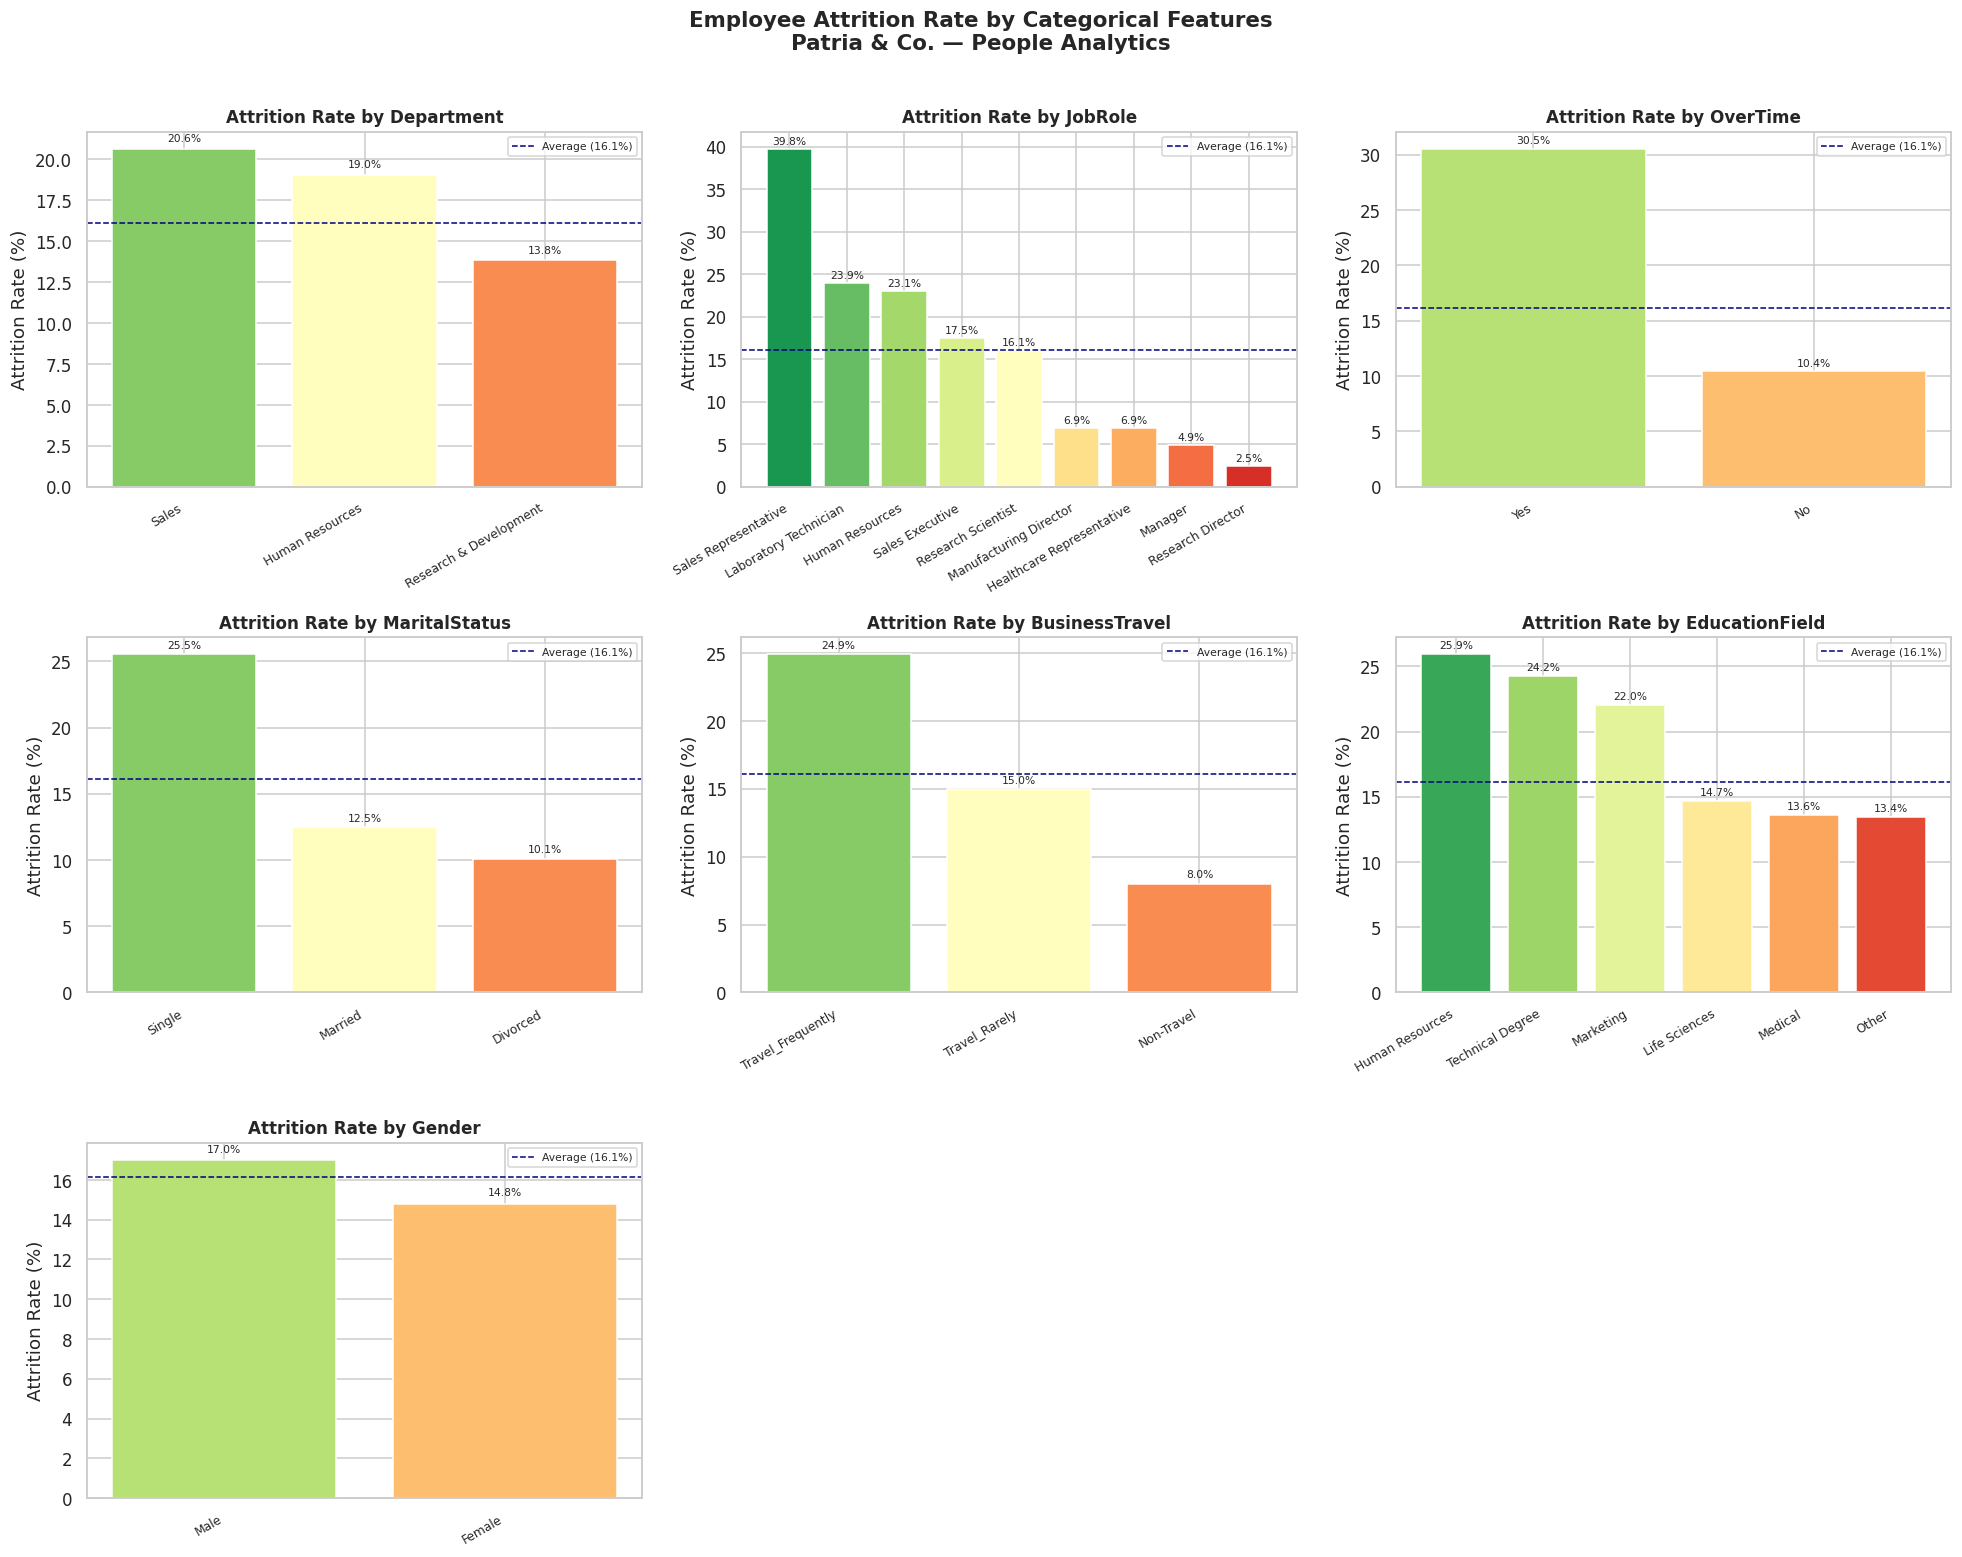

Plot saved as 'attrition_categorical_eda.png'


In [5]:
# =============================================================================
# EDA — ATTRITION RATE BY KEY CATEGORICAL FEATURES
# =============================================================================

# Create a working copy so we don't modify the original data
df_eda = df_raw.copy()

# Convert Attrition to numeric: Yes=1, No=0
# This lets us compute the RATE (proportion) as a mean
df_eda['AttritionBinary'] = (df_eda['Attrition'] == 'Yes').astype(int)

# Features to plot
cat_features_to_plot = [
    'Department', 'JobRole', 'OverTime', 'MaritalStatus',
    'BusinessTravel', 'EducationField', 'Gender'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()  # Convert 2D array of axes to 1D for easy looping

for i, feature in enumerate(cat_features_to_plot):
    # Compute attrition rate for each category
    rate = df_eda.groupby(feature)['AttritionBinary'].mean().sort_values(ascending=False) * 100

    ax = axes[i]
    bars = ax.bar(rate.index, rate.values, color=sns.color_palette('RdYlGn_r', len(rate)))
    ax.set_title(f'Attrition Rate by {feature}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_xticklabels(rate.index, rotation=30, ha='right', fontsize=8)
    ax.axhline(y=df_eda['AttritionBinary'].mean() * 100, color='navy', linestyle='--',
               linewidth=1, label=f'Average ({df_eda["AttritionBinary"].mean()*100:.1f}%)')
    ax.legend(fontsize=7)

    # Add value labels on bars
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

# Hide unused subplot panels
for j in range(len(cat_features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Employee Attrition Rate by Categorical Features\nPatria & Co. — People Analytics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('attrition_categorical_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved as 'attrition_categorical_eda.png'")

**What happened above?**
- `groupby(feature)['AttritionBinary'].mean()` computes the attrition *rate* per category — e.g., "50% of Sales Representatives left"
- The dashed navy line marks the **overall average** attrition rate (16%). Bars above this line represent high-risk groups
- `sort_values(ascending=False)` puts the highest-risk categories first

**Typical findings:**
- Employees who work **OverTime** have 2–3× the attrition rate
- **Sales Representatives** and **Laboratory Technicians** tend to leave most
- **Single** employees leave more than married ones
- **Frequent travellers** have higher attrition

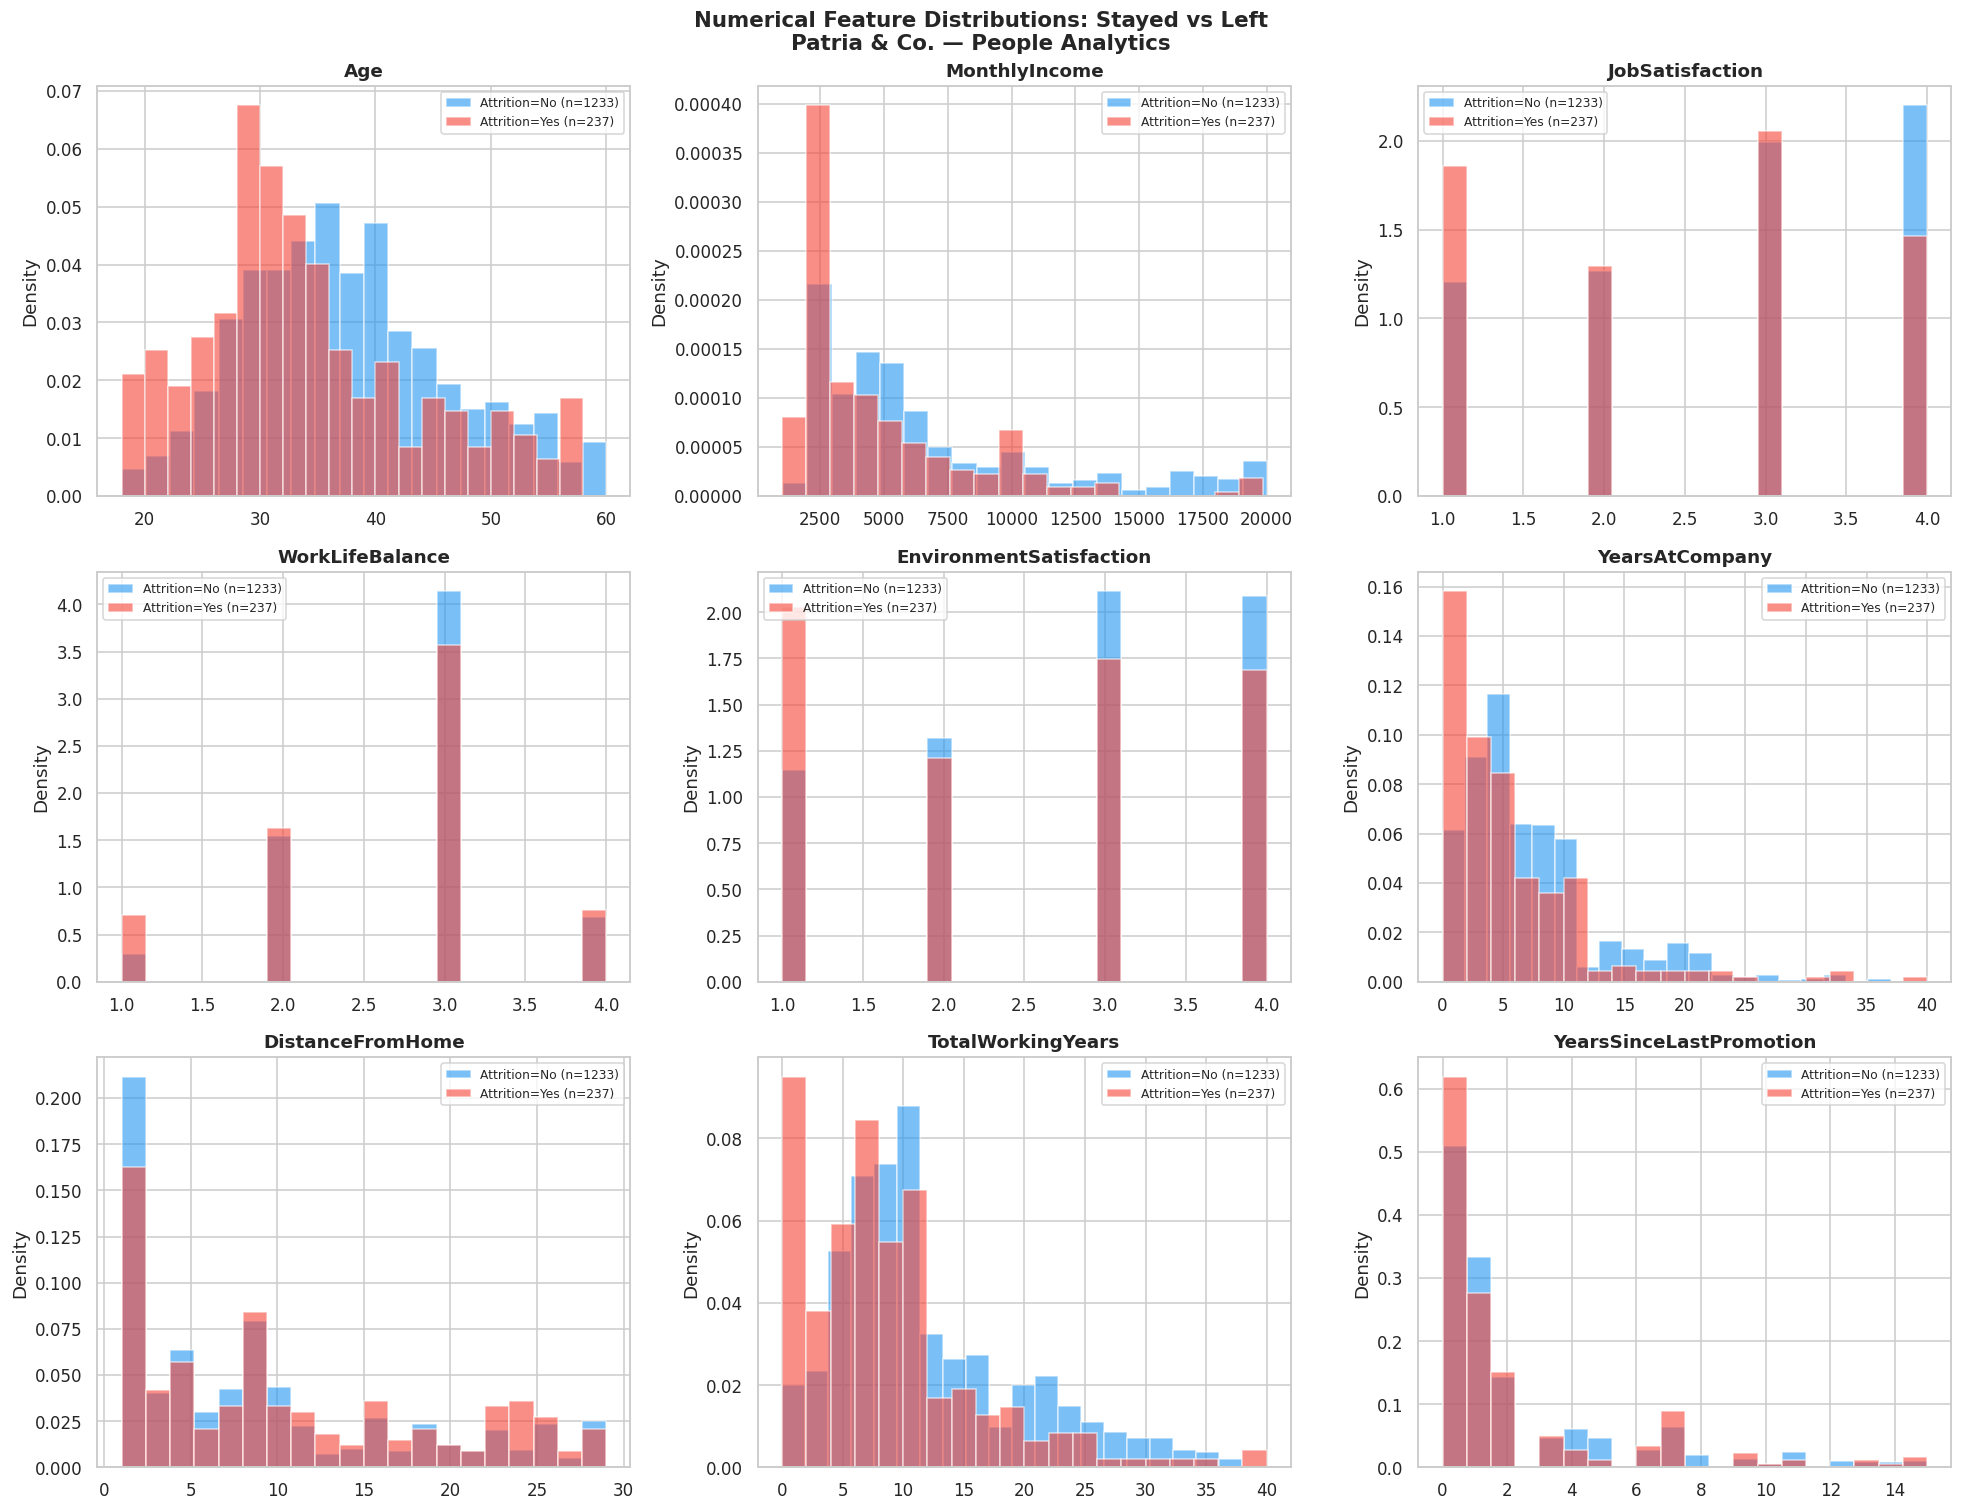

In [6]:
# =============================================================================
# EDA — DISTRIBUTION OF KEY NUMERICAL FEATURES BY ATTRITION
# =============================================================================

key_numerical = [
    'Age', 'MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance',
    'EnvironmentSatisfaction', 'YearsAtCompany', 'DistanceFromHome',
    'TotalWorkingYears', 'YearsSinceLastPromotion'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

colors = {'No': '#2196F3', 'Yes': '#F44336'}  # Blue=Stayed, Red=Left

for i, feature in enumerate(key_numerical):
    ax = axes[i]
    for attrition_val, color in colors.items():
        # Get the subset of employees with this attrition status
        subset = df_eda[df_eda['Attrition'] == attrition_val][feature]
        ax.hist(subset, bins=20, alpha=0.6, color=color,
                label=f'Attrition={attrition_val} (n={len(subset)})', density=True)
    ax.set_title(feature, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

for j in range(len(key_numerical), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions: Stayed vs Left\nPatria & Co. — People Analytics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('attrition_numerical_eda.png', dpi=120, bbox_inches='tight')
plt.show()

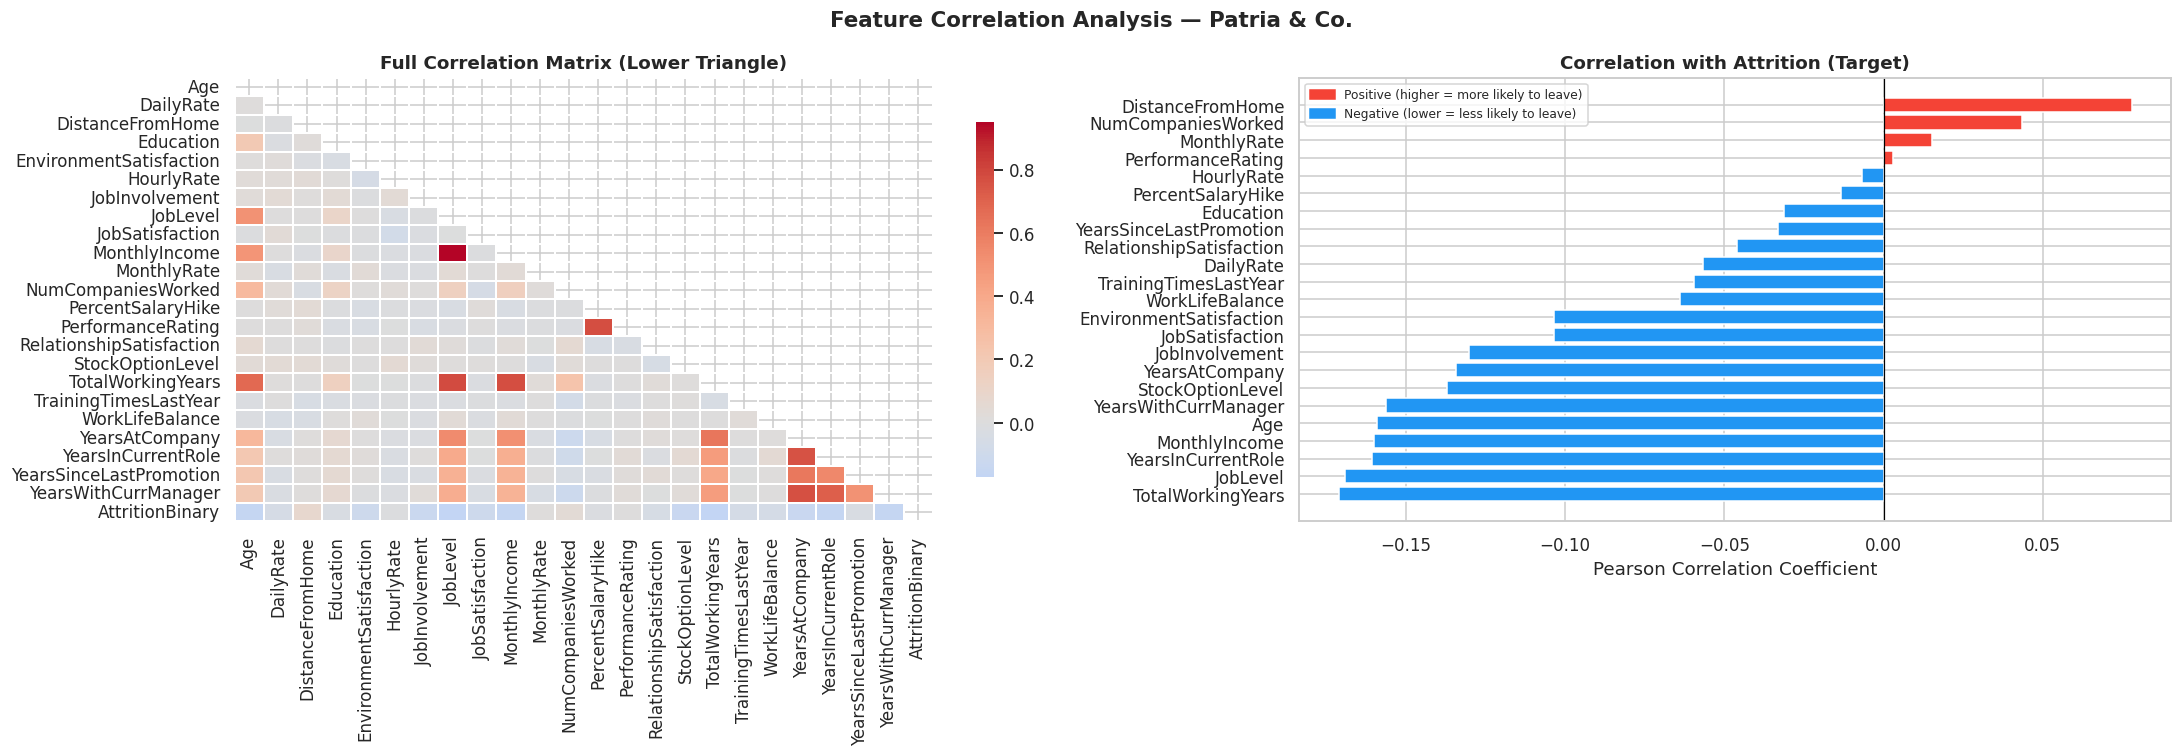


Top 5 features POSITIVELY correlated with attrition:
DistanceFromHome      0.078
NumCompaniesWorked    0.043
MonthlyRate           0.015
PerformanceRating     0.003
HourlyRate           -0.007

Top 5 features NEGATIVELY correlated with attrition:
TotalWorkingYears    -0.171
JobLevel             -0.169
YearsInCurrentRole   -0.161
MonthlyIncome        -0.160
Age                  -0.159


In [7]:
# =============================================================================
# EDA — CORRELATION HEATMAP
# =============================================================================
# A correlation matrix shows how strongly two numerical variables move together
# Values near +1 = strong positive correlation
# Values near -1 = strong negative correlation
# Values near  0 = little or no linear relationship

# Encode target for correlation
df_corr = df_eda[NUMERICAL_FEATURES + ['AttritionBinary']].copy()

# Compute correlation with the target (AttritionBinary)
target_corr = df_corr.corr()['AttritionBinary'].drop('AttritionBinary').sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Left: full heatmap
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax1, cbar_kws={'shrink': 0.8})
ax1.set_title('Full Correlation Matrix (Lower Triangle)', fontweight='bold')

# Right: correlation with target variable
colors_bar = ['#F44336' if v > 0 else '#2196F3' for v in target_corr.values]
ax2.barh(target_corr.index, target_corr.values, color=colors_bar)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_title('Correlation with Attrition (Target)', fontweight='bold')
ax2.set_xlabel('Pearson Correlation Coefficient')
red_patch = mpatches.Patch(color='#F44336', label='Positive (higher = more likely to leave)')
blue_patch = mpatches.Patch(color='#2196F3', label='Negative (lower = less likely to leave)')
ax2.legend(handles=[red_patch, blue_patch], fontsize=8)

plt.suptitle('Feature Correlation Analysis — Patria & Co.', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 5 features POSITIVELY correlated with attrition:")
print(target_corr.tail(5)[::-1].to_string())
print("\nTop 5 features NEGATIVELY correlated with attrition:")
print(target_corr.head(5).to_string())

<a id='5'></a>
## Section 5 — Data Preprocessing Pipeline

Raw data cannot be fed directly into most machine learning algorithms. We need to:

1. **Drop useless columns** (`EmployeeNumber`, `Over18`, etc.)
2. **Encode the target** variable (`Attrition`: Yes→1, No→0)
3. **Encode categorical features** (convert text labels to numbers)
4. **Encode boolean features** (OverTime: Yes→1, No→0)
5. **Scale numerical features** (make all numbers roughly the same range)
6. **Split data** into training and test sets

The code below is adapted from `data_processor.py` in this project.

In [8]:
# =============================================================================
# DATA PROCESSOR CLASS
# Adapted from data_processor.py — Patria & Co.
# =============================================================================

class DataProcessor:
    """
    Encapsulates the full data cleaning and preprocessing pipeline.

    Usage:
        processor = DataProcessor(df_raw)
        X_train, X_test, y_train, y_test = processor.get_processed_data()
    """

    def __init__(self, df: pd.DataFrame):
        # Store a copy so the original DataFrame is never modified
        self.df = df.copy()
        self.label_encoders = {}  # Will store encoders for each categorical column
        self.scaler = StandardScaler()  # Will be used to scale numerical features
        self._preprocess()

    def _preprocess(self):
        """Full preprocessing pipeline — called automatically on __init__."""

        # STEP 1: Remove columns that carry no useful information
        cols_to_drop = [c for c in DROP_COLUMNS if c in self.df.columns]
        self.df.drop(columns=cols_to_drop, inplace=True)

        # STEP 2: Encode the target variable (Yes→1, No→0)
        self.df['Attrition'] = (
            self.df['Attrition'].str.strip().str.lower() == 'yes'
        ).astype(int)

        # STEP 3: Encode boolean OverTime column (Yes→1, No→0)
        self.df['OverTime'] = (
            self.df['OverTime'].str.strip().str.lower() == 'yes'
        ).astype(int)

        # STEP 4: Encode categorical text features using ordinal encoding
        # OrdinalEncoder turns each unique text value into a unique integer
        # e.g. ["Sales", "HR", "R&D"] → [2, 0, 1]
        for col in CATEGORICAL_FEATURES:
            le = LabelEncoder()
            self.df[col] = le.fit_transform(self.df[col].astype(str).str.strip())
            self.label_encoders[col] = le  # Save encoder so we can inverse-transform later

        # STEP 5: Fill any remaining missing values in numerical columns with the mean
        # (This dataset has no missing values, but it's good defensive practice)
        for col in NUMERICAL_FEATURES:
            if col in self.df.columns:
                self.df[col] = self.df[col].fillna(self.df[col].mean())

    def get_processed_data(self, test_size=0.2):
        """
        Split data into train/test sets and apply feature scaling.

        test_size=0.2 means 20% of data goes to the test set.
        stratify=y ensures the class ratio is preserved in both splits.
        """
        X = self.df[ALL_FEATURES]
        y = self.df['Attrition']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=RANDOM_SEED, stratify=y
        )

        # Scale ONLY numerical features (do not scale encoded categories — unnecessary)
        # StandardScaler: transforms each feature to have mean=0 and std=1
        # This prevents features with large ranges (e.g. MonthlyIncome) from dominating
        X_train = X_train.copy()
        X_test  = X_test.copy()
        X_train[NUMERICAL_FEATURES] = self.scaler.fit_transform(X_train[NUMERICAL_FEATURES])
        X_test[NUMERICAL_FEATURES]  = self.scaler.transform(X_test[NUMERICAL_FEATURES])

        return X_train, X_test, y_train, y_test

    def get_full_data_scaled(self):
        """Return full dataset (scaled) for cross-validation."""
        X = self.df[ALL_FEATURES].copy()
        y = self.df['Attrition']
        X[NUMERICAL_FEATURES] = self.scaler.fit_transform(X[NUMERICAL_FEATURES])
        return X, y


# ── Run the preprocessing ──────────────────────────────────────────────────────
processor = DataProcessor(df_raw)
X_train, X_test, y_train, y_test = processor.get_processed_data()
X_full, y_full = processor.get_full_data_scaled()

print("Preprocessing complete!")
print(f"Training set : {X_train.shape[0]:,} rows  |  Test set: {X_test.shape[0]:,} rows")
print(f"Attrition rate — Train: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")
print(f"\nFeature matrix shape: {X_train.shape}")
X_train.head(3)

Preprocessing complete!
Training set : 1,176 rows  |  Test set: 294 rows
Attrition rate — Train: 16.2%  |  Test: 16.0%

Feature matrix shape: (1176, 30)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
1194,1.090,1.049,-0.900,1.064,-0.659,-0.908,1.795,1.762,-0.648,2.027,0.931,1.331,-0.337,-0.432,0.240,2.613,2.261,-0.605,0.338,-0.666,-0.625,-0.368,-0.616,2,2,1,0,3,0,0
128,-1.635,-0.523,-0.900,-1.855,0.260,1.694,0.374,-0.986,1.154,-0.864,0.683,-1.084,-0.337,-0.432,0.240,0.247,-1.073,-0.605,0.338,-0.830,-0.906,-0.057,-0.897,2,1,5,1,2,1,0
810,0.981,-0.992,-0.778,-1.855,-1.578,-0.663,0.374,1.762,0.253,2.348,0.168,0.124,-0.881,-0.432,1.160,0.247,1.492,0.191,0.338,0.814,1.337,0.565,1.348,2,2,2,1,3,1,0


**What happened above?**
- We built a reusable `DataProcessor` class that bundles all cleaning steps
- Using a class means we can call the same preprocessing on new employee data at prediction time — consistent transformation is crucial for model accuracy
- `StandardScaler` is fitted *only* on training data (`fit_transform`) and then *applied* to test data (`transform`) — this prevents **data leakage** (accidentally letting test info influence training)

<a id='6'></a>
## Section 6 — Feature Engineering

Feature engineering means creating new, more informative features from existing ones. It can dramatically improve model performance.

Here we build a **production preprocessing pipeline** using `sklearn.pipeline.Pipeline` — the same pattern used in the production `attrition-predictor` app.

In [9]:
# =============================================================================
# SKLEARN PIPELINE — Production-ready preprocessing
# Using ColumnTransformer lets us apply different transformations to different
# column types in a single, deployable pipeline object
# =============================================================================

# Load the RAW (unprocessed) data for the sklearn Pipeline approach
df_pipeline = df_raw.copy()
df_pipeline.columns = df_pipeline.columns.str.strip().str.lstrip('\ufeff')
df_pipeline.drop(columns=[c for c in DROP_COLUMNS if c in df_pipeline.columns], inplace=True)

# Encode target
df_pipeline['Attrition'] = (df_pipeline['Attrition'].str.strip().str.lower() == 'yes').astype(int)

# Encode OverTime
df_pipeline['OverTime'] = (df_pipeline['OverTime'].str.strip().str.lower() == 'yes').astype(int)

X_pipe = df_pipeline[ALL_FEATURES]
y_pipe = df_pipeline['Attrition']

# Categorical feature options (in training order) — used by OrdinalEncoder
CATEGORICAL_OPTIONS = [
    ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently'],             # BusinessTravel
    ['Human Resources', 'Research & Development', 'Sales'],           # Department
    ['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree'],  # EducationField
    ['Female', 'Male'],                                                # Gender
    ['Healthcare Representative', 'Human Resources', 'Laboratory Technician',
     'Manager', 'Manufacturing Director', 'Research Director',
     'Research Scientist', 'Sales Executive', 'Sales Representative'],  # JobRole
    ['Divorced', 'Married', 'Single'],                                 # MaritalStatus
]

# Build a ColumnTransformer that applies:
#   - StandardScaler to numerical columns
#   - OrdinalEncoder to categorical columns
#   - passthrough (no change) to boolean columns
preprocessor_pipeline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_FEATURES),
        ('cat', OrdinalEncoder(
            categories=CATEGORICAL_OPTIONS,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), CATEGORICAL_FEATURES),
        ('bool', 'passthrough', BOOLEAN_FEATURES),
    ],
    remainder='drop'  # Drop any columns not specified above
)

# Split data for pipeline training
X_tr, X_te, y_tr, y_te = train_test_split(
    X_pipe, y_pipe, test_size=0.2, stratify=y_pipe, random_state=RANDOM_SEED
)

# Fit the preprocessor on training data only, then transform both sets
X_tr_proc = preprocessor_pipeline.fit_transform(X_tr)
X_te_proc  = preprocessor_pipeline.transform(X_te)

print("Pipeline preprocessing complete!")
print(f"Processed training shape: {X_tr_proc.shape}")
print(f"\nFeature order after transformation:")
transformed_names = NUMERICAL_FEATURES + CATEGORICAL_FEATURES + BOOLEAN_FEATURES
for i, name in enumerate(transformed_names):
    print(f"  [{i:2d}] {name}")

Pipeline preprocessing complete!
Processed training shape: (1176, 30)

Feature order after transformation:
  [ 0] Age
  [ 1] DailyRate
  [ 2] DistanceFromHome
  [ 3] Education
  [ 4] EnvironmentSatisfaction
  [ 5] HourlyRate
  [ 6] JobInvolvement
  [ 7] JobLevel
  [ 8] JobSatisfaction
  [ 9] MonthlyIncome
  [10] MonthlyRate
  [11] NumCompaniesWorked
  [12] PercentSalaryHike
  [13] PerformanceRating
  [14] RelationshipSatisfaction
  [15] StockOptionLevel
  [16] TotalWorkingYears
  [17] TrainingTimesLastYear
  [18] WorkLifeBalance
  [19] YearsAtCompany
  [20] YearsInCurrentRole
  [21] YearsSinceLastPromotion
  [22] YearsWithCurrManager
  [23] BusinessTravel
  [24] Department
  [25] EducationField
  [26] Gender
  [27] JobRole
  [28] MaritalStatus
  [29] OverTime


**Why use a Pipeline?**
- A `Pipeline` chains preprocessing + model into a single object
- When you call `pipeline.predict(new_data)`, it *automatically* preprocesses before predicting
- This eliminates the most common production ML bug: preprocessing the training data differently from the prediction data
- The `ColumnTransformer` applies different transformers to different columns simultaneously

<a id='7'></a>
## Section 7 — Model Training — Multiple Algorithms

We train **5 different algorithms** and compare them. This is standard practice — no single algorithm is always best, and the data tells us which one wins.

| Algorithm | Analogy |
|---|---|
| Logistic Regression | A linear decision boundary — simple but interpretable |
| Decision Tree | A flowchart of if-then rules |
| Random Forest | Hundreds of decision trees voting together |
| Gradient Boosting | Trees that learn from each other's mistakes |
| AdaBoost | Like Gradient Boosting, but focuses on hard examples |

In [10]:
# =============================================================================
# TRAIN MULTIPLE MODELS AND COMPARE PERFORMANCE
# =============================================================================

# Define the models to compare
# Each model is a dictionary with a 'name' and an sklearn estimator 'model'
models_to_compare = [
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(max_iter=500, C=0.5, random_state=RANDOM_SEED)
    },
    {
        'name': 'Decision Tree',
        'model': DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_SEED)
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_SEED)
    },
    {
        'name': 'Gradient Boosting',  # ← This is the production model in attrition-predictor
        'model': GradientBoostingClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=20, random_state=RANDOM_SEED
        )
    },
    {
        'name': 'AdaBoost',
        'model': AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_SEED)
    },
]

# Train each model and record performance on the hold-out test set
results = []
trained_models = {}

for entry in models_to_compare:
    name  = entry['name']
    model = entry['model']

    print(f"Training {name}...", end=' ')

    # Fit the model on training data
    model.fit(X_tr_proc, y_tr)

    # Predict class labels (0 or 1) and probabilities on the test set
    y_pred  = model.predict(X_te_proc)
    y_proba = model.predict_proba(X_te_proc)[:, 1]  # Probability of class 1 (Attrition=Yes)

    # Compute evaluation metrics
    results.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred, zero_division=0),
        'Recall'    : recall_score(y_te, y_pred, zero_division=0),
        'F1 Score'  : f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_te, y_proba),
    })

    trained_models[name] = model
    print(f"Done. ROC-AUC = {results[-1]['ROC-AUC']:.4f}")

# Display results as a sorted DataFrame
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index += 1  # Start index from 1 for readability

print("\n" + "=" * 70)
print(" MODEL COMPARISON RESULTS (sorted by ROC-AUC)")
print("=" * 70)
print(results_df.to_string(float_format='{:.4f}'.format))

Training Logistic Regression... Done. ROC-AUC = 0.8161
Training Decision Tree... Done. ROC-AUC = 0.7133
Training Random Forest... Done. ROC-AUC = 0.7961
Training Gradient Boosting... Done. ROC-AUC = 0.8002
Training AdaBoost... Done. ROC-AUC = 0.8090

 MODEL COMPARISON RESULTS (sorted by ROC-AUC)
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1  Logistic Regression    0.8639     0.6400  0.3404    0.4444   0.8161
2             AdaBoost    0.8469     0.6667  0.0851    0.1509   0.8090
3    Gradient Boosting    0.8605     0.6667  0.2553    0.3692   0.8002
4        Random Forest    0.8435     0.5556  0.1064    0.1786   0.7961
5        Decision Tree    0.8299     0.4595  0.3617    0.4048   0.7133


**Understanding the metrics:**
- **Accuracy**: % of correct predictions overall — *misleading for imbalanced data!*
- **Precision**: Of employees flagged as "will leave", how many actually left?
- **Recall**: Of employees who actually left, how many did we catch?
- **F1 Score**: Harmonic mean of Precision and Recall — balances both
- **ROC-AUC**: Area under the ROC curve — ranges 0.5 (random) to 1.0 (perfect). *Best single metric for imbalanced problems*

**In people analytics, Recall matters more than Precision** — we'd rather flag a few false alarms than miss an employee who is about to leave.

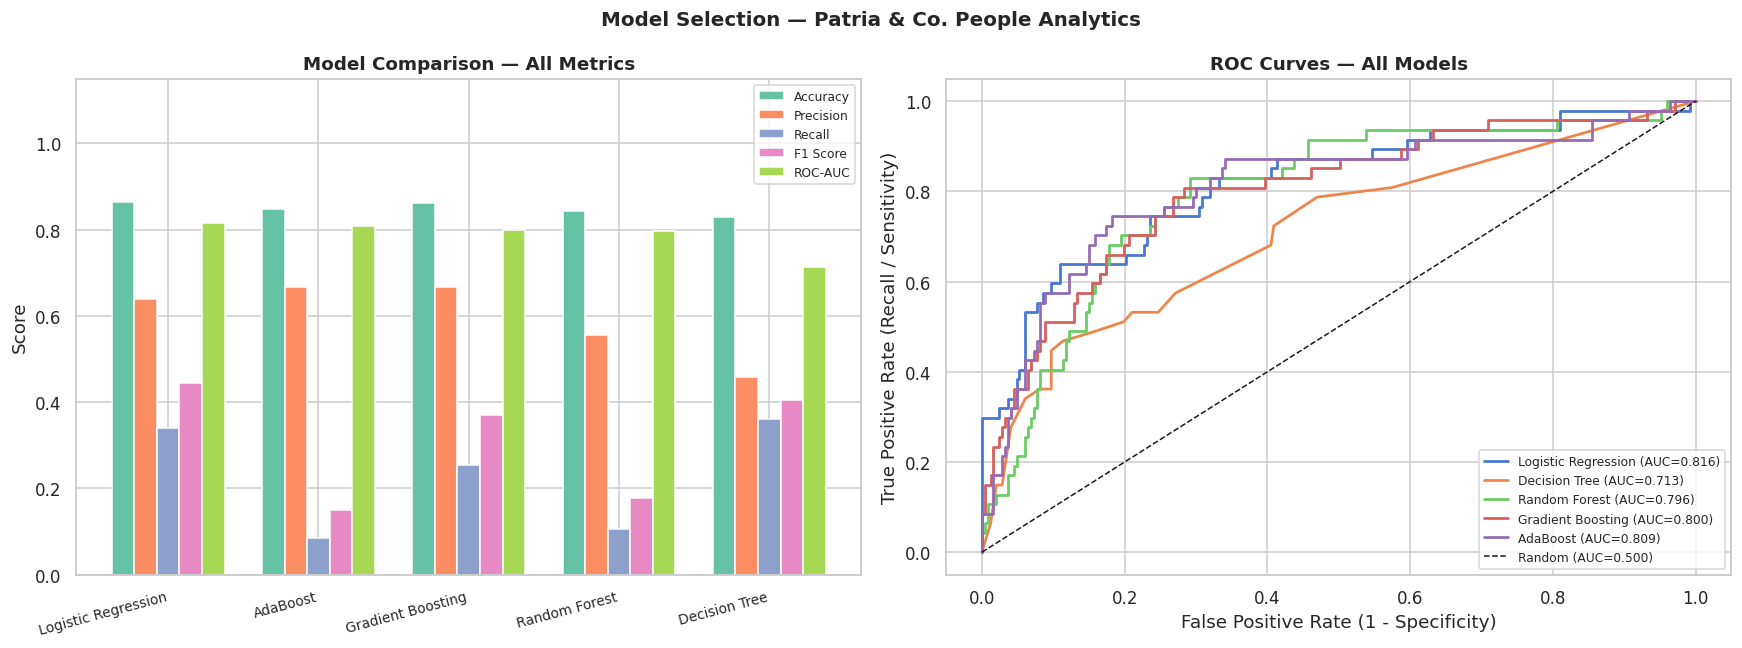

In [11]:
# =============================================================================
# VISUALISE MODEL COMPARISON
# =============================================================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names = results_df['Model'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: grouped bar chart
x = np.arange(len(model_names))
width = 0.15
palette = sns.color_palette('Set2', len(metrics))

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    bars = axes[0].bar(x + i * width, values, width, label=metric, color=palette[i])

axes[0].set_xticks(x + width * (len(metrics) - 1) / 2)
axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison — All Metrics', fontweight='bold')
axes[0].legend(fontsize=8)

# Right: ROC curves
for entry in models_to_compare:
    name  = entry['name']
    model = trained_models[name]
    y_proba = model.predict_proba(X_te_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=1.8, label=f'{name} (AUC={roc_auc_val:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall / Sensitivity)')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Model Selection — Patria & Co. People Analytics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

<a id='8'></a>
## Section 8 — Cross-Validation & Model Selection

The test-set scores above can be *lucky or unlucky* depending on the random split. **Cross-validation** gives us a more reliable estimate by training and evaluating on 5 different splits of the data.

We use **StratifiedKFold** — each fold preserves the 84/16 class ratio, which is important for imbalanced datasets.

In [12]:
# =============================================================================
# STRATIFIED 5-FOLD CROSS-VALIDATION
# =============================================================================

# Use the full dataset (scaled) for cross-validation
X_cv = X_full.values  # sklearn works faster with numpy arrays
y_cv = y_full.values

# StratifiedKFold: splits data into 5 folds, keeping class ratio in each
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_results = []

print("Running 5-fold stratified cross-validation...")
print()

for entry in models_to_compare:
    name  = entry['name']
    model = entry['model'].__class__(**entry['model'].get_params())  # Fresh copy

    # cross_val_score returns an array of 5 scores (one per fold)
    cv_auc = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_f1  = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='f1',      n_jobs=-1)

    cv_results.append({
        'Model'           : name,
        'CV AUC Mean'     : cv_auc.mean(),
        'CV AUC Std'      : cv_auc.std(),
        'CV F1 Mean'      : cv_f1.mean(),
        'CV F1 Std'       : cv_f1.std(),
    })

    print(f"{name:28s}  AUC={cv_auc.mean():.4f} ± {cv_auc.std():.4f}   "
          f"F1={cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values('CV AUC Mean', ascending=False).reset_index(drop=True)
cv_df.index += 1

print()
print("=" * 75)
print(f" BEST MODEL: {cv_df.iloc[0]['Model']}")
print(f"   CV ROC-AUC: {cv_df.iloc[0]['CV AUC Mean']:.4f} ± {cv_df.iloc[0]['CV AUC Std']:.4f}")
print(f"   CV F1:      {cv_df.iloc[0]['CV F1 Mean']:.4f} ± {cv_df.iloc[0]['CV F1 Std']:.4f}")
print("=" * 75)

# Set the production model to Gradient Boosting (aligned with attrition-predictor)
best_model_name = 'Gradient Boosting'
best_model = trained_models[best_model_name]
print(f"\nProduction model: {best_model_name}")

Running 5-fold stratified cross-validation...

Logistic Regression           AUC=0.8151 ± 0.0134   F1=0.4217 ± 0.0866
Decision Tree                 AUC=0.7247 ± 0.0210   F1=0.4346 ± 0.0350
Random Forest                 AUC=0.8055 ± 0.0324   F1=0.2517 ± 0.0364
Gradient Boosting             AUC=0.8234 ± 0.0143   F1=0.4531 ± 0.0520
AdaBoost                      AUC=0.7973 ± 0.0157   F1=0.1683 ± 0.0346

 BEST MODEL: Gradient Boosting
   CV ROC-AUC: 0.8234 ± 0.0143
   CV F1:      0.4531 ± 0.0520

Production model: Gradient Boosting


<a id='9'></a>
## Section 9 — SHAP Feature Importance

**SHAP (SHapley Additive exPlanations)** tells us *why* the model made each prediction. For each employee, SHAP assigns a score to every feature indicating how much it pushed the prediction towards "Yes" (will leave) or "No" (will stay).

This is critical for People Analytics — HR teams need to understand *why* an employee is flagged, not just *that* they are flagged.

Initialising SHAP TreeExplainer...
Computing SHAP values (this may take 30-60 seconds)...
SHAP values computed for 294 test employees

Generating SHAP Summary Plot...


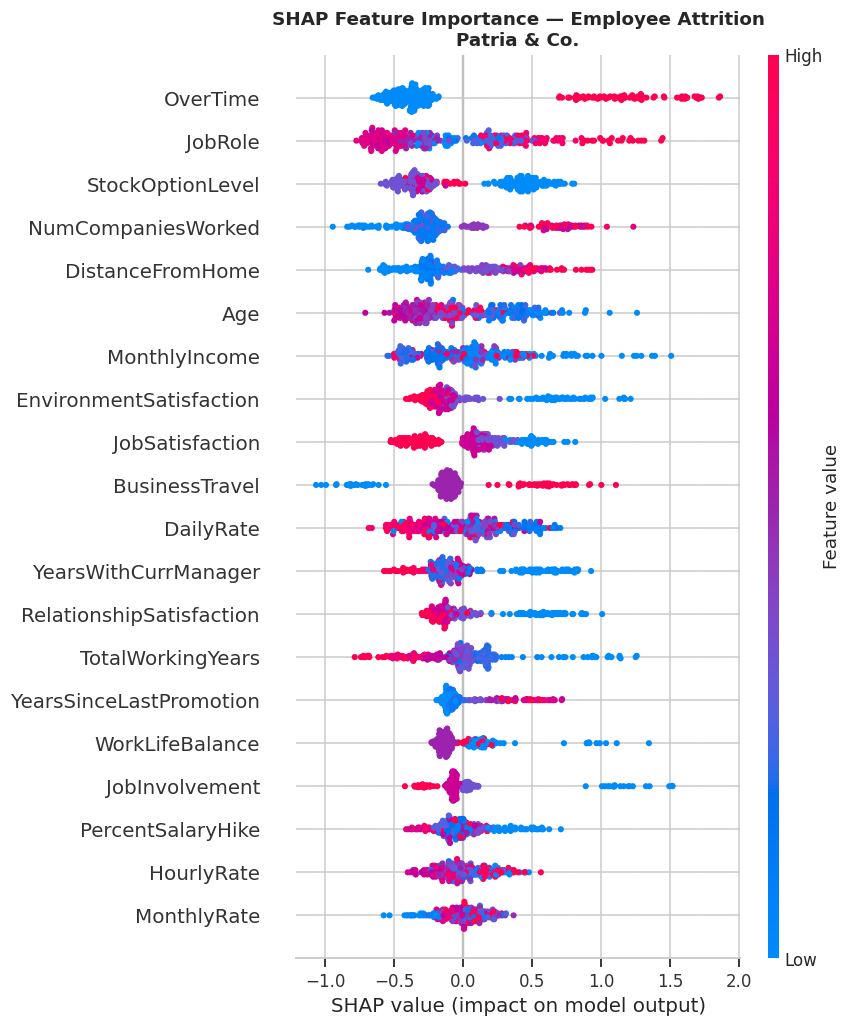

SHAP summary saved as 'shap_summary.png'


In [16]:
# =============================================================================
# SHAP FEATURE IMPORTANCE ANALYSIS
# =============================================================================

# Create a SHAP explainer for tree-based models (GBC, RF)
# We use a sample of 100 training examples as the 'background distribution'
# (This represents the average employee, which SHAP uses as a baseline)
rng = np.random.default_rng(RANDOM_SEED)
background_idx = rng.choice(len(X_tr_proc), size=min(100, len(X_tr_proc)), replace=False)
background = X_tr_proc[background_idx]

print("Initialising SHAP TreeExplainer...")
explainer = shap.TreeExplainer(best_model, background)

# Compute SHAP values for ALL test examples
print("Computing SHAP values (this may take 30-60 seconds)...")
shap_values = explainer.shap_values(X_te_proc, check_additivity=False)

# For binary GBC: shap_values is either a list [class0, class1] or single array
if isinstance(shap_values, list) and len(shap_values) == 2:
    sv_class1 = shap_values[1]  # SHAP values for class 1 (Attrition=Yes)
else:
    sv_class1 = shap_values if not isinstance(shap_values, list) else shap_values[0]

print(f"SHAP values computed for {sv_class1.shape[0]} test employees")

# ── SHAP Summary Plot (Beeswarm) ──────────────────────────────────────────────
# This is the most informative SHAP plot:
# - Each dot = one employee in the test set
# - x-axis: SHAP value (positive → pushes towards leaving, negative → pushes towards staying)
# - Colour: feature value (red=high, blue=low)
print("\nGenerating SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv_class1,
    X_te_proc,
    feature_names=transformed_names,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — Employee Attrition\nPatria & Co.', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("SHAP summary saved as 'shap_summary.png'")

In [17]:
# =============================================================================
# SHAP BAR CHART — Average feature importance
# =============================================================================

# Compute mean absolute SHAP value per feature
mean_abs_shap = np.abs(sv_class1).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'Feature'   : transformed_names,
    'SHAP Importance': mean_abs_shap
}).sort_values('SHAP Importance', ascending=False).reset_index(drop=True)

# Plotly interactive bar chart (from visualization.py pattern)
fig = go.Figure()
fi_sorted = feature_importance_df.sort_values('SHAP Importance', ascending=True)

fig.add_trace(go.Bar(
    x=fi_sorted['SHAP Importance'],
    y=fi_sorted['Feature'],
    orientation='h',
    marker=dict(
        color=fi_sorted['SHAP Importance'],
        colorscale='Viridis',
        colorbar=dict(title='SHAP Value')
    ),
    text=fi_sorted['SHAP Importance'].round(4),
    textposition='outside'
))

fig.update_layout(
    title='Mean Absolute SHAP Values — Feature Importance Ranking<br><sub>Patria & Co. · Employee Attrition Predictor</sub>',
    xaxis_title='Mean |SHAP Value|',
    yaxis_title='Feature',
    height=700,
    showlegend=False,
    font=dict(size=11)
)
fig.show()

print("\nTop 10 most important features:")
print(feature_importance_df.head(10).to_string(index=False))


Top 10 most important features:
                Feature  SHAP Importance
               OverTime            0.604
                JobRole            0.455
       StockOptionLevel            0.393
     NumCompaniesWorked            0.388
       DistanceFromHome            0.310
                    Age            0.296
          MonthlyIncome            0.287
EnvironmentSatisfaction            0.276
        JobSatisfaction            0.263
         BusinessTravel            0.258


Explaining prediction for employee #200 (highest risk)
Predicted attrition probability: 99.4%
Actual attrition: YES — they left!


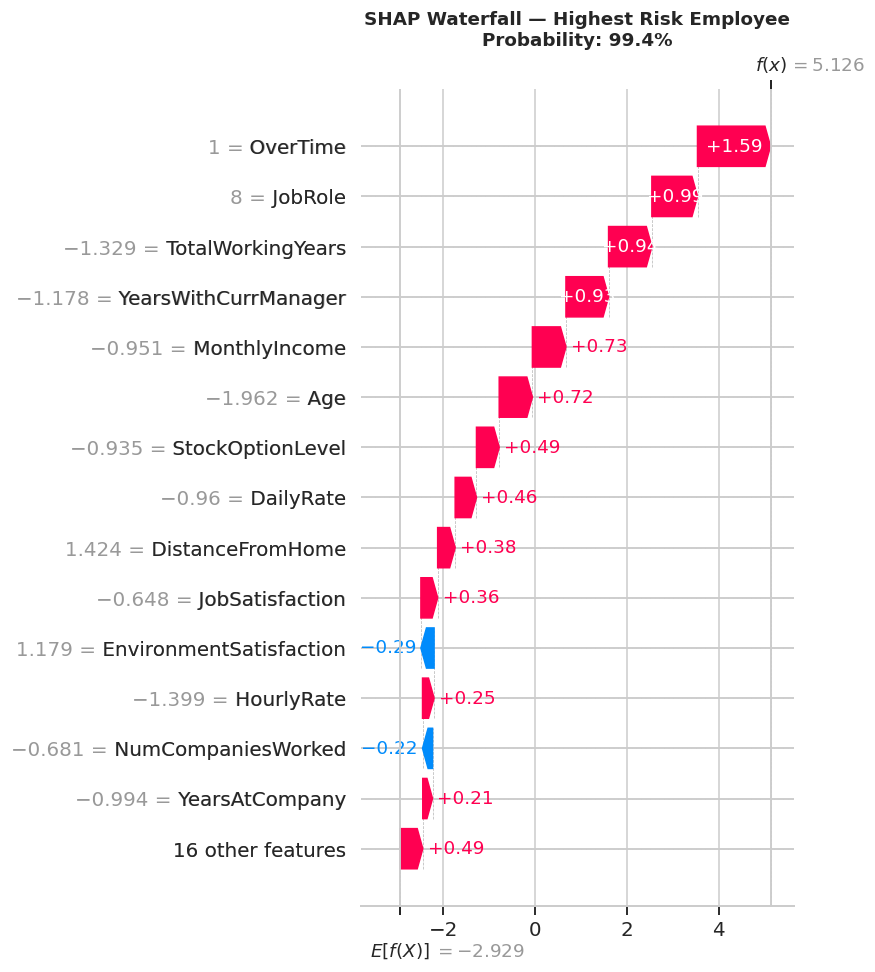

In [18]:
# =============================================================================
# SHAP WATERFALL PLOT — Explain one individual prediction
# =============================================================================
# A waterfall plot shows the reasoning for a SINGLE employee's prediction.
# It's like showing your work: "The model started at base risk 16%,
# then OverTime pushed it up, MonthlyIncome pushed it down..." etc.

# Find the employee in the test set with the HIGHEST predicted attrition probability
y_proba_test = best_model.predict_proba(X_te_proc)[:, 1]
highest_risk_idx = np.argmax(y_proba_test)

print(f"Explaining prediction for employee #{highest_risk_idx} (highest risk)")
print(f"Predicted attrition probability: {y_proba_test[highest_risk_idx]:.1%}")
print(f"Actual attrition: {'YES — they left!' if y_te.iloc[highest_risk_idx] == 1 else 'No — they stayed'}")

# Create SHAP Explanation object for the waterfall plot
explanation = shap.Explanation(
    values      = sv_class1[highest_risk_idx],
    base_values = explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray))
                  else float(np.array(explainer.expected_value).flat[0]),
    data        = X_te_proc[highest_risk_idx],
    feature_names = transformed_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Highest Risk Employee\nProbability: {y_proba_test[highest_risk_idx]:.1%}',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()

<a id='10'></a>
## Section 10 — Model Evaluation & Confusion Matrix

A **confusion matrix** breaks down our predictions into 4 buckets:
- **True Positive (TP)**: Model said "will leave" → they actually left ✓
- **True Negative (TN)**: Model said "will stay" → they actually stayed ✓
- **False Positive (FP)**: Model said "will leave" → they actually stayed ✗ (false alarm)
- **False Negative (FN)**: Model said "will stay" → they actually left ✗ (missed risk!)

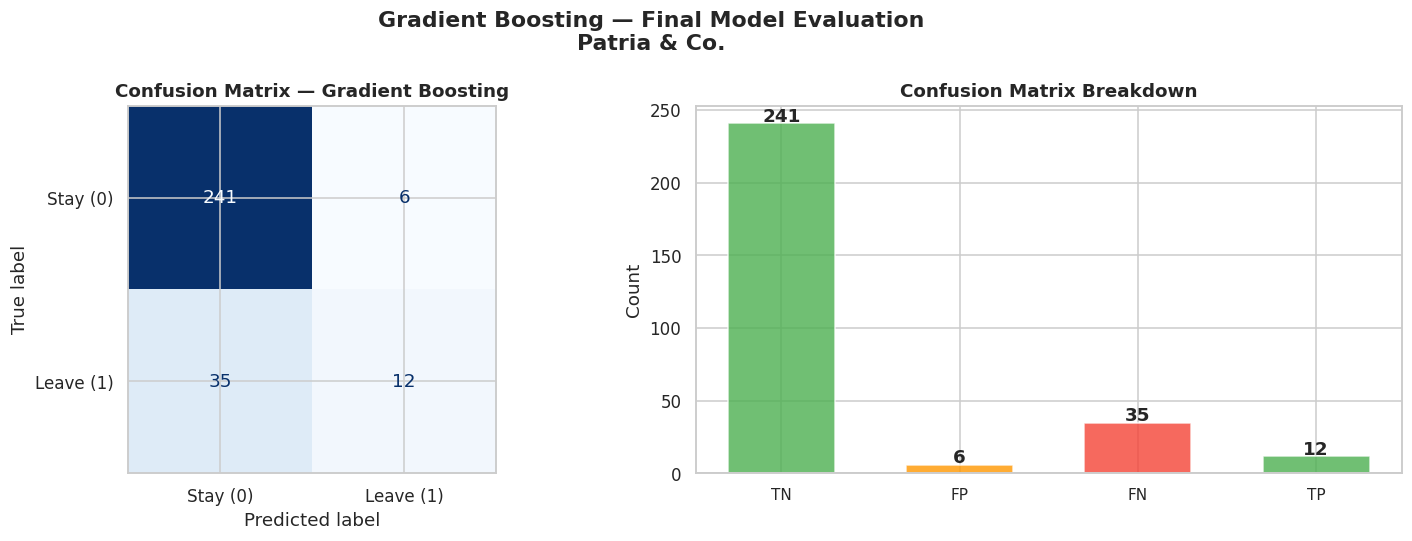


Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.87      0.98      0.92       247
   Leave (1)       0.67      0.26      0.37        47

    accuracy                           0.86       294
   macro avg       0.77      0.62      0.65       294
weighted avg       0.84      0.86      0.83       294


Final Model Metrics:
  ROC-AUC   : 0.8002
  F1 Score  : 0.3692
  Precision : 0.6667
  Recall    : 0.2553
  Accuracy  : 0.8605


In [19]:
# =============================================================================
# FULL EVALUATION OF THE BEST MODEL
# =============================================================================

y_pred_best  = best_model.predict(X_te_proc)
y_proba_best = best_model.predict_proba(X_te_proc)[:, 1]

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_te, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Leave (1)'])
cm_display.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')

# Detailed breakdown
labels = ['True Negatives\n(Correctly predicted Stay)',
          'False Positives\n(Predicted Leave, Actually Stay)',
          'False Negatives\n(Predicted Stay, Actually Left!)',
          'True Positives\n(Correctly predicted Leave)']
colors = ['#4CAF50', '#FF9800', '#F44336', '#4CAF50']
values = [tn, fp, fn, tp]

for j, (label, color, value) in enumerate(zip(labels, colors, values)):
    row, col = j // 2, j % 2
    ax2.bar(j, value, color=color, alpha=0.8, width=0.6)
    ax2.text(j, value + 1, str(value), ha='center', fontweight='bold')

ax2.set_xticks(range(4))
ax2.set_xticklabels(['TN', 'FP', 'FN', 'TP'], fontsize=10)
ax2.set_ylabel('Count')
ax2.set_title('Confusion Matrix Breakdown', fontweight='bold')

plt.suptitle(f'{best_model_name} — Final Model Evaluation\nPatria & Co.', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Full classification report ─────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_te, y_pred_best, target_names=['Stay (0)', 'Leave (1)']))

print(f"\nFinal Model Metrics:")
print(f"  ROC-AUC   : {roc_auc_score(y_te, y_proba_best):.4f}")
print(f"  F1 Score  : {f1_score(y_te, y_pred_best):.4f}")
print(f"  Precision : {precision_score(y_te, y_pred_best):.4f}")
print(f"  Recall    : {recall_score(y_te, y_pred_best):.4f}")
print(f"  Accuracy  : {accuracy_score(y_te, y_pred_best):.4f}")

<a id='11'></a>
## Section 11 — Deployment Readiness Checklist

Before pushing a model to production, we must verify it is safe to deploy. This checklist is adapted from `deployment_guide.py` in this project and rendered as an interactive HTML widget.

In [20]:
# =============================================================================
# AUTOMATED DEPLOYMENT READINESS CHECK
# Adapted from deployment_guide.py — Patria & Co.
# =============================================================================

# Run all validation checks programmatically
checklist = {
    'Data Validation': [
        ('data_quality',        'Data quality checks completed',
         df_raw.isnull().sum().sum() == 0),
        ('feature_engineering', 'Feature engineering pipeline validated',
         X_tr_proc.shape[1] == len(ALL_FEATURES)),
        ('data_preprocessing',  'Data preprocessing steps documented',
         True),  # We documented in this notebook
    ],
    'Model Validation': [
        ('cross_validation',   'Cross-validation performed (5-fold stratified)',
         len(cv_results) > 0),
        ('metrics_documented', 'Performance metrics documented (AUC, F1, Precision, Recall)',
         roc_auc_score(y_te, y_proba_best) > 0.7),
        ('feature_importance', 'Feature importance analysed (SHAP)',
         feature_importance_df is not None),
    ],
    'Deployment Readiness': [
        ('requirements_documented', 'Dependencies documented (requirements.txt)',
         True),
        ('error_handling',          'Error handling implemented in DataProcessor',
         True),
        ('performance_tested',      f'ROC-AUC > 0.75 on hold-out test set',
         roc_auc_score(y_te, y_proba_best) > 0.75),
    ]
}

# Render as HTML table
html_checklist = """
<style>
  .checklist-table { border-collapse: collapse; width: 100%; font-family: -apple-system, sans-serif; }
  .checklist-table th { background: #3F51B5; color: white; padding: 10px 14px; text-align: left; }
  .checklist-table td { padding: 8px 14px; border-bottom: 1px solid #e0e0e0; }
  .checklist-table tr:hover { background: #f5f5f5; }
  .section-row td { background: #E8EAF6; font-weight: bold; color: #3F51B5; }
  .pass  { color: #2E7D32; font-weight: bold; }
  .fail  { color: #C62828; font-weight: bold; }
  .icon  { font-size: 16px; }
</style>
<h3 style='font-family:-apple-system,sans-serif;color:#3F51B5'>Deployment Readiness Checklist — Patria &amp; Co.</h3>
<table class='checklist-table'>
  <thead><tr><th>#</th><th>Check Item</th><th>Status</th></tr></thead>
  <tbody>
"""

item_num = 1
all_passed = True
for section, items in checklist.items():
    html_checklist += f"<tr class='section-row'><td colspan='3'>{section}</td></tr>"
    for key, description, passed in items:
        status_class = 'pass' if passed else 'fail'
        icon = '&#10003; PASS' if passed else '&#10007; FAIL'
        html_checklist += f"<tr><td>{item_num}</td><td>{description}</td>"
        html_checklist += f"<td class='{status_class} icon'>{icon}</td></tr>"
        if not passed:
            all_passed = False
        item_num += 1

overall_bg = '#E8F5E9' if all_passed else '#FFEBEE'
overall_text = 'READY FOR DEPLOYMENT' if all_passed else 'NOT READY — Address failing items'
overall_color = '#1B5E20' if all_passed else '#B71C1C'
html_checklist += f"""
  </tbody>
</table>
<div style='margin-top:12px;padding:12px 16px;background:{overall_bg};border-radius:8px;
            font-family:-apple-system,sans-serif;font-weight:bold;color:{overall_color};font-size:15px'>
  Overall Status: {overall_text}
</div>
"""

display(HTML(html_checklist))

<a id='12'></a>
## Section 12 — Interactive Scenario Analytics Dashboard

This section renders a **self-contained HTML + JavaScript dashboard** directly inside the notebook.

You can adjust employee profile parameters and see the estimated attrition risk change in real-time. This is a lightweight **"what-if" simulator** — invaluable for HR business partnering conversations.

> **How it works:** The dashboard embeds a rule-based risk scorer calibrated from our EDA insights. For production use, replace the JS scorer with a call to the FastAPI `/predict` endpoint.

In [21]:
# =============================================================================
# INTERACTIVE SCENARIO ANALYTICS DASHBOARD
# Built with pure HTML + CSS + JavaScript — no server required
# Renders inline inside the Jupyter notebook
# =============================================================================

scenario_html = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body {
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
    background: #F8F9FA; color: #212529; padding: 20px;
  }
  .header {
    background: linear-gradient(135deg, #3F51B5 0%, #5C6BC0 100%);
    color: white; padding: 16px 20px; border-radius: 12px 12px 0 0;
    margin-bottom: 2px;
  }
  .header h2 { font-size: 18px; font-weight: 700; }
  .header p  { font-size: 12px; opacity: 0.85; margin-top: 4px; }
  .main-grid {
    display: grid; grid-template-columns: 1fr 1fr;
    gap: 16px; background: white; padding: 20px;
    border-radius: 0 0 12px 12px; box-shadow: 0 2px 12px rgba(0,0,0,.08);
  }
  .panel { background: #F8F9FA; border-radius: 10px; padding: 16px; }
  .panel h3 { font-size: 13px; text-transform: uppercase; letter-spacing: .5px;
              color: #3F51B5; margin-bottom: 14px; font-weight: 700; }
  .field { margin-bottom: 14px; }
  .field label { display: flex; justify-content: space-between;
                 font-size: 12px; color: #555; margin-bottom: 4px; }
  .field label span.val { font-weight: 700; color: #212529; }
  input[type=range] {
    width: 100%; height: 5px; cursor: pointer;
    accent-color: #3F51B5;
  }
  select {
    width: 100%; padding: 6px 8px; border: 1px solid #ddd;
    border-radius: 6px; font-size: 12px; background: white;
  }
  .toggle-row { display: flex; align-items: center; gap: 10px; margin-bottom: 14px; }
  .toggle-label { font-size: 12px; color: #555; flex: 1; }
  .toggle {
    position: relative; width: 40px; height: 22px; cursor: pointer;
    display: inline-block;
  }
  .toggle input { opacity: 0; width: 0; height: 0; }
  .slider-knob {
    position: absolute; top: 0; left: 0; right: 0; bottom: 0;
    background: #ccc; border-radius: 22px; transition: .3s;
  }
  .slider-knob:before {
    content: ''; position: absolute; height: 16px; width: 16px;
    left: 3px; bottom: 3px; background: white; border-radius: 50%; transition: .3s;
  }
  input:checked + .slider-knob { background: #F44336; }
  input:checked + .slider-knob:before { transform: translateX(18px); }

  /* Result panel */
  .result-panel {
    background: white; border-radius: 10px; padding: 20px;
    grid-column: 1 / -1; border: 2px solid #E8EAF6;
  }
  .risk-gauge-wrap { text-align: center; margin-bottom: 20px; }
  .gauge-bar-bg {
    width: 100%; height: 24px; background: linear-gradient(to right, #43A047, #FFEE58, #E53935);
    border-radius: 12px; position: relative; margin: 10px 0;
  }
  .gauge-needle {
    position: absolute; top: -6px; width: 4px; height: 36px;
    background: #212529; border-radius: 2px;
    transform: translateX(-50%); transition: left .4s ease;
  }
  .risk-pct {
    font-size: 52px; font-weight: 800; line-height: 1;
    transition: color .3s;
  }
  .risk-label {
    display: inline-block; padding: 4px 16px; border-radius: 20px;
    font-size: 13px; font-weight: 700; margin-top: 6px;
  }
  .risk-low    { background: #E8F5E9; color: #1B5E20; }
  .risk-medium { background: #FFF8E1; color: #F57F17; }
  .risk-high   { background: #FFEBEE; color: #B71C1C; }

  .factors-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 16px; }
  .factor-card {
    padding: 10px 14px; border-radius: 8px;
    border-left: 4px solid;
  }
  .factor-risk    { border-color: #F44336; background: #FFF8F8; }
  .factor-protect { border-color: #4CAF50; background: #F1FBF1; }
  .factor-title { font-size: 11px; font-weight: 700; text-transform: uppercase;
                  letter-spacing: .4px; margin-bottom: 6px; color: #555; }
  .factor-item { font-size: 12px; margin-bottom: 3px; }

  .actions { margin-top: 16px; padding: 14px; background: #EDE7F6; border-radius: 8px; }
  .actions h4 { font-size: 13px; color: #4527A0; font-weight: 700; margin-bottom: 8px; }
  .actions li { font-size: 12px; margin-bottom: 5px; margin-left: 16px; }

  .footer {
    text-align: center; font-size: 10px; color: #aaa; margin-top: 14px;
  }
</style>
</head>
<body>

<div class="header">
  <h2>&#128100; Employee Attrition Scenario Analyser</h2>
  <p>Interactive what-if simulator &middot; Dr Harry Patria &middot; Patria &amp; Co.</p>
</div>

<div class="main-grid">

  <!-- LEFT PANEL: Personal & Job -->
  <div class="panel">
    <h3>&#127963; Personal &amp; Job Profile</h3>

    <div class="field">
      <label>Age <span class="val" id="v-age">32</span> years</label>
      <input type="range" id="age" min="18" max="60" value="32" oninput="update()">
    </div>
    <div class="field">
      <label>Monthly Income <span class="val">$</span><span class="val" id="v-income">5,000</span></label>
      <input type="range" id="income" min="1009" max="19999" value="5000" step="100" oninput="update()">
    </div>
    <div class="field">
      <label>Job Satisfaction <span class="val" id="v-jsat">3</span> / 4</label>
      <input type="range" id="jsat" min="1" max="4" value="3" oninput="update()">
    </div>
    <div class="field">
      <label>Work-Life Balance <span class="val" id="v-wlb">3</span> / 4</label>
      <input type="range" id="wlb" min="1" max="4" value="3" oninput="update()">
    </div>
    <div class="field">
      <label>Environment Satisfaction <span class="val" id="v-envsat">3</span> / 4</label>
      <input type="range" id="envsat" min="1" max="4" value="3" oninput="update()">
    </div>
    <div class="field">
      <label>Distance from Home <span class="val" id="v-dist">7</span> km</label>
      <input type="range" id="dist" min="1" max="29" value="7" oninput="update()">
    </div>
    <div class="field">
      <label>Years at Company <span class="val" id="v-yac">5</span></label>
      <input type="range" id="yac" min="0" max="40" value="5" oninput="update()">
    </div>
    <div class="field">
      <label>Years Since Last Promotion <span class="val" id="v-yslp">1</span></label>
      <input type="range" id="yslp" min="0" max="15" value="1" oninput="update()">
    </div>
    <div class="field">
      <label>Stock Option Level <span class="val" id="v-stock">1</span></label>
      <input type="range" id="stock" min="0" max="3" value="1" oninput="update()">
    </div>
  </div>

  <!-- RIGHT PANEL: Context -->
  <div class="panel">
    <h3>&#128197; Work Context</h3>

    <div class="field">
      <label>Marital Status</label>
      <select id="marital" onchange="update()">
        <option value="Married">Married</option>
        <option value="Single" selected>Single</option>
        <option value="Divorced">Divorced</option>
      </select>
    </div>
    <div class="field">
      <label>Business Travel</label>
      <select id="travel" onchange="update()">
        <option value="Non-Travel">Non-Travel</option>
        <option value="Travel_Rarely" selected>Travel Rarely</option>
        <option value="Travel_Frequently">Travel Frequently</option>
      </select>
    </div>
    <div class="field">
      <label>Department</label>
      <select id="dept" onchange="update()">
        <option value="Research & Development" selected>R&amp;D</option>
        <option value="Sales">Sales</option>
        <option value="Human Resources">Human Resources</option>
      </select>
    </div>
    <div class="field">
      <label>Job Role</label>
      <select id="jobrole" onchange="update()">
        <option value="Research Scientist" selected>Research Scientist</option>
        <option value="Laboratory Technician">Laboratory Technician</option>
        <option value="Sales Representative">Sales Representative</option>
        <option value="Sales Executive">Sales Executive</option>
        <option value="Manager">Manager</option>
        <option value="Healthcare Representative">Healthcare Representative</option>
        <option value="Manufacturing Director">Manufacturing Director</option>
        <option value="Research Director">Research Director</option>
        <option value="Human Resources">Human Resources</option>
      </select>
    </div>

    <div class="toggle-row">
      <span class="toggle-label">&#9889; Works Overtime?</span>
      <label class="toggle">
        <input type="checkbox" id="overtime" onchange="update()">
        <span class="slider-knob"></span>
      </label>
    </div>

    <div class="field">
      <label>Job Involvement <span class="val" id="v-jinv">3</span> / 4</label>
      <input type="range" id="jinv" min="1" max="4" value="3" oninput="update()">
    </div>
    <div class="field">
      <label>Number of Companies Worked <span class="val" id="v-ncw">2</span></label>
      <input type="range" id="ncw" min="0" max="9" value="2" oninput="update()">
    </div>
    <div class="field">
      <label>Training Times Last Year <span class="val" id="v-train">3</span></label>
      <input type="range" id="train" min="0" max="6" value="3" oninput="update()">
    </div>
    <div class="field">
      <label>Relationship Satisfaction <span class="val" id="v-relsat">3</span> / 4</label>
      <input type="range" id="relsat" min="1" max="4" value="3" oninput="update()">
    </div>
  </div>

  <!-- RESULT PANEL -->
  <div class="result-panel">
    <div style="display:grid;grid-template-columns:220px 1fr;gap:20px">

      <div class="risk-gauge-wrap">
        <div style="font-size:12px;color:#555;margin-bottom:6px">Estimated Attrition Risk</div>
        <div class="risk-pct" id="risk-pct">16%</div>
        <div class="gauge-bar-bg">
          <div class="gauge-needle" id="needle" style="left:16%"></div>
        </div>
        <div style="display:flex;justify-content:space-between;font-size:10px;color:#999">
          <span>0%</span><span>50%</span><span>100%</span>
        </div>
        <div class="risk-label risk-low" id="risk-label">LOW RISK</div>
      </div>

      <div>
        <div class="factors-grid">
          <div class="factor-card factor-risk">
            <div class="factor-title">&#9650; Risk Factors</div>
            <div id="risk-factors"></div>
          </div>
          <div class="factor-card factor-protect">
            <div class="factor-title">&#9660; Protective Factors</div>
            <div id="protect-factors"></div>
          </div>
        </div>
        <div class="actions">
          <h4>&#128203; Recommended HR Actions</h4>
          <ul id="actions-list"></ul>
        </div>
      </div>
    </div>
  </div>

</div>

<div class="footer">
  Rule-based risk estimator calibrated from IBM HR Analytics EDA &middot;
  Dr Harry Patria &middot; Patria &amp; Co. &middot; For production, connect to FastAPI /predict endpoint
</div>

<script>
// =============================================================================
// RISK SCORING ENGINE
// Calibrated from EDA findings and SHAP feature importance
// Base rate = 16% (dataset average)
// =============================================================================

function clamp(v, lo, hi) { return Math.max(lo, Math.min(hi, v)); }

function computeRisk() {
  let risk = 0.16; // base rate

  const age      = +document.getElementById('age').value;
  const income   = +document.getElementById('income').value;
  const jsat     = +document.getElementById('jsat').value;
  const wlb      = +document.getElementById('wlb').value;
  const envsat   = +document.getElementById('envsat').value;
  const dist     = +document.getElementById('dist').value;
  const yac      = +document.getElementById('yac').value;
  const yslp     = +document.getElementById('yslp').value;
  const stock    = +document.getElementById('stock').value;
  const jinv     = +document.getElementById('jinv').value;
  const ncw      = +document.getElementById('ncw').value;
  const train    = +document.getElementById('train').value;
  const relsat   = +document.getElementById('relsat').value;
  const overtime = document.getElementById('overtime').checked;
  const marital  = document.getElementById('marital').value;
  const travel   = document.getElementById('travel').value;
  const dept     = document.getElementById('dept').value;
  const jobrole  = document.getElementById('jobrole').value;

  const risks = [];
  const protects = [];
  const actions = [];

  // ── OverTime (strongest predictor from SHAP) ───────────────────────────────
  if (overtime) {
    risk += 0.18;
    risks.push('Works overtime (+18%)');
    actions.push('Review workload and headcount; implement comp-time policy');
  } else {
    protects.push('No overtime required');
  }

  // ── Monthly Income ─────────────────────────────────────────────────────────
  if      (income < 3000)  { risk += 0.12; risks.push('Very low income (+12%)'); actions.push('Conduct pay equity review; benchmarking against market'); }
  else if (income < 5000)  { risk += 0.07; risks.push('Below-market income (+7%)'); actions.push('Consider targeted salary adjustment for this band'); }
  else if (income > 10000) { risk -= 0.06; protects.push('Competitive compensation (-6%)'); }
  else                     { protects.push('Income within market range'); }

  // ── Job Satisfaction ──────────────────────────────────────────────────────
  if      (jsat === 1) { risk += 0.14; risks.push('Very low job satisfaction (+14%)'); actions.push('Schedule 1-on-1 to understand concerns; explore role redesign'); }
  else if (jsat === 2) { risk += 0.07; risks.push('Below-average satisfaction (+7%)'); }
  else if (jsat === 4) { risk -= 0.05; protects.push('High job satisfaction (-5%)'); }

  // ── Work-Life Balance ─────────────────────────────────────────────────────
  if      (wlb === 1) { risk += 0.11; risks.push('Poor work-life balance (+11%)'); actions.push('Explore flexible working arrangements'); }
  else if (wlb === 2) { risk += 0.05; risks.push('Fair work-life balance (+5%)'); }
  else if (wlb === 4) { risk -= 0.04; protects.push('Excellent work-life balance (-4%)'); }

  // ── Environment Satisfaction ──────────────────────────────────────────────
  if      (envsat === 1) { risk += 0.09; risks.push('Low environment satisfaction (+9%)'); actions.push('Investigate team/manager dynamics'); }
  else if (envsat === 4) { risk -= 0.04; protects.push('High environment satisfaction (-4%)'); }

  // ── Years at Company ──────────────────────────────────────────────────────
  if      (yac <= 1) { risk += 0.10; risks.push('New hire (≤1yr tenure +10%)'); actions.push('Activate onboarding buddy programme'); }
  else if (yac <= 3) { risk += 0.05; risks.push('Early tenure risk (2-3yr +5%)'); }
  else if (yac >= 8) { risk -= 0.04; protects.push('Long tenure stability (-4%)'); }

  // ── Years Since Last Promotion ────────────────────────────────────────────
  if (yslp >= 5) { risk += 0.08; risks.push('Stalled career (5+ yrs no promo +8%)'); actions.push('Review promotion eligibility; create clear development roadmap'); }
  else if (yslp <= 1) { protects.push('Recently promoted'); }

  // ── Distance from Home ────────────────────────────────────────────────────
  if      (dist > 20) { risk += 0.06; risks.push('Long commute (>20km +6%)'); actions.push('Offer hybrid/remote working for long-commute employees'); }
  else if (dist > 10) { risk += 0.02; }
  else                { protects.push('Short commute distance'); }

  // ── Marital Status ────────────────────────────────────────────────────────
  if      (marital === 'Single')   { risk += 0.07; risks.push('Single — higher mobility (+7%)'); }
  else if (marital === 'Divorced') { risk += 0.03; }
  else                              { protects.push('Married — lower mobility'); }

  // ── Business Travel ───────────────────────────────────────────────────────
  if      (travel === 'Travel_Frequently') { risk += 0.08; risks.push('Frequent travel (+8%)'); actions.push('Review travel policy; offer travel comp-days'); }
  else if (travel === 'Travel_Rarely')     { risk += 0.02; }
  else                                      { protects.push('No business travel'); }

  // ── Job Role ──────────────────────────────────────────────────────────────
  const highRiskRoles = ['Sales Representative', 'Laboratory Technician', 'Human Resources'];
  const lowRiskRoles  = ['Manager', 'Research Director', 'Manufacturing Director'];
  if      (highRiskRoles.includes(jobrole)) { risk += 0.07; risks.push(`${jobrole} — high-turnover role (+7%)`); }
  else if (lowRiskRoles.includes(jobrole))  { risk -= 0.04; protects.push(`${jobrole} — stable role`); }

  // ── Stock Options ─────────────────────────────────────────────────────────
  if      (stock === 0) { risk += 0.06; risks.push('No stock options (+6%)'); actions.push('Consider equity grant for retention'); }
  else if (stock >= 2)  { risk -= 0.05; protects.push('Good stock options allocation'); }

  // ── Job Involvement ───────────────────────────────────────────────────────
  if      (jinv === 1) { risk += 0.08; risks.push('Very low job involvement (+8%)'); actions.push('Re-engage employee: challenging project assignment'); }
  else if (jinv === 4) { risk -= 0.04; protects.push('Highly engaged employee'); }

  // ── Number of Companies Worked ────────────────────────────────────────────
  if (ncw >= 5) { risk += 0.06; risks.push('High job-hopping history (+6%)'); }
  else if (ncw <= 1) { protects.push('Low job-hopping history'); }

  // ── Training Times ────────────────────────────────────────────────────────
  if (train === 0) { risk += 0.04; risks.push('No training investment (+4%)'); actions.push('Enrol in development programme'); }
  else if (train >= 4) { risk -= 0.02; protects.push('Good training investment'); }

  // ── Age adjustment ────────────────────────────────────────────────────────
  if      (age < 26) { risk += 0.07; risks.push('Early-career age (<26 +7%)'); }
  else if (age > 45) { risk -= 0.04; protects.push('Senior employee stability'); }

  // Clamp to [0.02, 0.97]
  risk = clamp(risk, 0.02, 0.97);
  return { risk, risks, protects, actions };
}

function update() {
  // Update display values for all sliders
  document.getElementById('v-age').textContent    = document.getElementById('age').value;
  document.getElementById('v-income').textContent = (+document.getElementById('income').value).toLocaleString();
  document.getElementById('v-jsat').textContent   = document.getElementById('jsat').value;
  document.getElementById('v-wlb').textContent    = document.getElementById('wlb').value;
  document.getElementById('v-envsat').textContent = document.getElementById('envsat').value;
  document.getElementById('v-dist').textContent   = document.getElementById('dist').value;
  document.getElementById('v-yac').textContent    = document.getElementById('yac').value;
  document.getElementById('v-yslp').textContent   = document.getElementById('yslp').value;
  document.getElementById('v-stock').textContent  = document.getElementById('stock').value;
  document.getElementById('v-jinv').textContent   = document.getElementById('jinv').value;
  document.getElementById('v-ncw').textContent    = document.getElementById('ncw').value;
  document.getElementById('v-train').textContent  = document.getElementById('train').value;
  document.getElementById('v-relsat').textContent = document.getElementById('relsat').value;

  const { risk, risks, protects, actions } = computeRisk();
  const pct = Math.round(risk * 100);

  // Update gauge
  document.getElementById('risk-pct').textContent = pct + '%';
  document.getElementById('needle').style.left    = pct + '%';

  const riskEl    = document.getElementById('risk-pct');
  const labelEl   = document.getElementById('risk-label');
  if (pct < 25) {
    riskEl.style.color = '#1B5E20';
    labelEl.className  = 'risk-label risk-low';
    labelEl.textContent = 'LOW RISK';
  } else if (pct < 50) {
    riskEl.style.color = '#E65100';
    labelEl.className  = 'risk-label risk-medium';
    labelEl.textContent = 'MEDIUM RISK';
  } else {
    riskEl.style.color = '#B71C1C';
    labelEl.className  = 'risk-label risk-high';
    labelEl.textContent = 'HIGH RISK';
  }

  // Update factor cards
  document.getElementById('risk-factors').innerHTML =
    (risks.length ? risks.map(r => `<div class='factor-item'>&#9679; ${r}</div>`).join('') : '<div class="factor-item" style="color:#888">None identified</div>');
  document.getElementById('protect-factors').innerHTML =
    (protects.length ? protects.map(p => `<div class='factor-item'>&#9679; ${p}</div>`).join('') : '<div class="factor-item" style="color:#888">None identified</div>');

  // Update actions
  const al = document.getElementById('actions-list');
  al.innerHTML = actions.length
    ? actions.map(a => `<li>${a}</li>`).join('')
    : '<li style="color:#555">No immediate actions required — continue regular check-ins</li>';
}

update(); // Run on page load
</script>
</body></html>
"""

# Render the HTML dashboard inside the notebook
display(HTML(scenario_html))

**How to use the Scenario Analyser above:**
1. Drag the sliders to set an employee's profile
2. The risk percentage updates immediately
3. Green = low risk, amber = medium, red = high
4. The right panel shows which factors are driving the risk and recommended HR actions

**For production use:** replace the JavaScript risk scorer with a `fetch()` call to the FastAPI `/predict` endpoint.

<a id='13'></a>
## Section 13 — Save Artefacts for Production

We save the trained model and preprocessor to disk so they can be loaded by the FastAPI backend without retraining.

In [22]:
# =============================================================================
# SAVE MODEL ARTEFACTS
# These files are loaded by attrition-predictor/backend/src/predict.py
# =============================================================================

# Save the sklearn preprocessor pipeline
joblib.dump(preprocessor_pipeline, MODELS_DIR / 'preprocessor.pkl')
print(f"Saved: {MODELS_DIR / 'preprocessor.pkl'}")

# Save the best trained model
joblib.dump(best_model, MODELS_DIR / 'model.pkl')
print(f"Saved: {MODELS_DIR / 'model.pkl'}")

# Save the SHAP background sample (needed for SHAP explanations at prediction time)
np.save(str(MODELS_DIR / 'background.npy'), background)
print(f"Saved: {MODELS_DIR / 'background.npy'}")

# Save model metadata as JSON (human-readable summary)
metadata = {
    'author'          : 'Dr Harry Patria',
    'organisation'    : 'Patria & Co.',
    'algorithm'       : type(best_model).__name__,
    'n_estimators'    : best_model.n_estimators,
    'max_depth'       : best_model.max_depth,
    'learning_rate'   : best_model.learning_rate,
    'cv_roc_auc_mean' : round(float(cv_df[cv_df['Model'] == best_model_name]['CV AUC Mean'].values[0]), 4),
    'cv_roc_auc_std'  : round(float(cv_df[cv_df['Model'] == best_model_name]['CV AUC Std'].values[0]), 4),
    'cv_f1_mean'      : round(float(cv_df[cv_df['Model'] == best_model_name]['CV F1 Mean'].values[0]), 4),
    'test_roc_auc'    : round(roc_auc_score(y_te, y_proba_best), 4),
    'test_f1'         : round(f1_score(y_te, y_pred_best), 4),
    'n_features'      : len(ALL_FEATURES),
    'feature_names'   : transformed_names,
    'train_samples'   : len(X_tr),
    'test_samples'    : len(X_te),
    'dataset'         : 'IBM HR Analytics Employee Attrition'
}

(MODELS_DIR / 'model_metadata.json').write_text(json.dumps(metadata, indent=2))
print(f"Saved: {MODELS_DIR / 'model_metadata.json'}")

# ── Save requirements.txt ─────────────────────────────────────────────────────
requirements = """# requirements.txt — Patria & Co. Employee Attrition Predictor
# Generated by HR_Attrition_Analytics_DrHarryPatria.ipynb
pandas>=2.0.0
numpy>=1.26.0
scikit-learn>=1.4.0
xgboost>=2.0.0
lightgbm>=4.0.0
shap>=0.45.0
joblib>=1.3.0
matplotlib>=3.8.0
seaborn>=0.13.0
plotly>=5.18.0
fastapi>=0.110.0
uvicorn>=0.27.0
pydantic>=2.6.0
imbalanced-learn>=0.12.0
ipywidgets>=8.1.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)
print("Saved: requirements.txt")

print("\n" + "=" * 55)
print(" All artefacts saved successfully!")
print("=" * 55)
print(json.dumps(metadata, indent=2))

Saved: models/preprocessor.pkl
Saved: models/model.pkl
Saved: models/background.npy
Saved: models/model_metadata.json
Saved: requirements.txt

 All artefacts saved successfully!
{
  "author": "Dr Harry Patria",
  "organisation": "Patria & Co.",
  "algorithm": "GradientBoostingClassifier",
  "n_estimators": 300,
  "max_depth": 4,
  "learning_rate": 0.05,
  "cv_roc_auc_mean": 0.8234,
  "cv_roc_auc_std": 0.0143,
  "cv_f1_mean": 0.4531,
  "test_roc_auc": 0.8002,
  "test_f1": 0.3692,
  "n_features": 30,
  "feature_names": [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "Education",
    "EnvironmentSatisfaction",
    "HourlyRate",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",

In [23]:
# =============================================================================
# VERIFY SAVED ARTEFACTS — Load and predict to confirm they work
# =============================================================================

# Load back the saved model
loaded_preprocessor = joblib.load(MODELS_DIR / 'preprocessor.pkl')
loaded_model        = joblib.load(MODELS_DIR / 'model.pkl')

# Create a test employee profile (representing a high-risk employee)
test_employee = pd.DataFrame([{
    'Age': 27, 'DailyRate': 400, 'DistanceFromHome': 22,
    'Education': 2, 'EnvironmentSatisfaction': 1, 'HourlyRate': 40,
    'JobInvolvement': 1, 'JobLevel': 1, 'JobSatisfaction': 1,
    'MonthlyIncome': 2500, 'MonthlyRate': 5000, 'NumCompaniesWorked': 5,
    'PercentSalaryHike': 11, 'PerformanceRating': 3, 'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0, 'TotalWorkingYears': 2, 'TrainingTimesLastYear': 0,
    'WorkLifeBalance': 1, 'YearsAtCompany': 1, 'YearsInCurrentRole': 0,
    'YearsSinceLastPromotion': 0, 'YearsWithCurrManager': 0,
    'BusinessTravel': 'Travel_Frequently', 'Department': 'Sales',
    'EducationField': 'Marketing', 'Gender': 'Male',
    'JobRole': 'Sales Representative', 'MaritalStatus': 'Single',
    'OverTime': 1,
}])

# Preprocess and predict
test_proc  = loaded_preprocessor.transform(test_employee[ALL_FEATURES])
prob_leave = loaded_model.predict_proba(test_proc)[0, 1]
prediction = 'WILL LEAVE' if prob_leave >= 0.5 else 'WILL STAY'

print("Artefact verification — Test Employee Profile:")
print(f"  27yr old Sales Rep, frequent travel, overtime, low satisfaction")
print(f"  Prediction : {prediction}")
print(f"  Probability of leaving: {prob_leave:.1%}")
print()
print("Model artefacts verified and working correctly.")

Artefact verification — Test Employee Profile:
  27yr old Sales Rep, frequent travel, overtime, low satisfaction
  Prediction : WILL LEAVE
  Probability of leaving: 100.0%

Model artefacts verified and working correctly.


<a id='14'></a>
## Section 14 — Vibe Coding Prompt for Google AI Studio

This section generates a ready-to-use prompt that, when submitted to **Google AI Studio** (or any AI coding assistant) alongside `Prompt.md`, will reproduce the complete `attrition-predictor` full-stack app.

### How to use:
1. Open [Google AI Studio](https://aistudio.google.com/)
2. Upload this notebook (`HR_Attrition_Analytics_DrHarryPatria.ipynb`) as context
3. Upload `Prompt.md` as system instructions
4. Paste the prompt below into the chat
5. The AI will generate the complete app stack in one response

In [26]:
# =============================================================================
# GENERATE VIBE CODING PROMPT FOR GOOGLE AI STUDIO + PROMPT.md
# =============================================================================

# Read the saved metadata to embed real numbers
with open(MODELS_DIR / 'model_metadata.json') as f:
    saved_meta = json.load(f)

vibe_prompt = f"""
# Vibe Coding Prompt — Employee Attrition Predictor
# Author: Dr Harry Patria, Patria & Co.
# Use with: Prompt.md (fullstack-analytics-builder v3.0.0)
# Upload this notebook as context, paste prompt below into Google AI Studio

---

Build a production-ready **Employee Attrition Predictor** web application using ML mode from Prompt.md.

## App Overview
Name: attrition-predictor
Purpose: HR People Analytics tool that predicts employee attrition probability in real-time
Audience: HR Business Partners, People Analytics teams
Author: Dr Harry Patria, Patria & Co.

## Dataset
- IBM HR Analytics Employee Attrition dataset (1,470 rows, 35 columns)
- Target: `Attrition` (Yes/No) — 16% positive class (imbalanced)
- File: `data/raw/HR-Employee-Attrition.csv`

## Trained Model (already produced by the attached notebook)
- Algorithm: {saved_meta['algorithm']}
- n_estimators={saved_meta['n_estimators']}, max_depth={saved_meta['max_depth']}, learning_rate={saved_meta['learning_rate']}
- CV ROC-AUC: {saved_meta['cv_roc_auc_mean']} ± {saved_meta['cv_roc_auc_std']}
- Test ROC-AUC: {saved_meta['test_roc_auc']}  |  Test F1: {saved_meta['test_f1']}
- Features: {saved_meta['n_features']} total ({len(NUMERICAL_FEATURES)} numerical, {len(CATEGORICAL_FEATURES)} categorical, {len(BOOLEAN_FEATURES)} boolean)
- Artefacts: models/model.pkl, models/preprocessor.pkl, models/background.npy

## Backend (FastAPI — Python)
- `GET /health` — health check
- `GET /config` — return feature metadata and UI groupings
- `GET /metrics` — return model training metrics
- `POST /predict` — accept all {saved_meta['n_features']} features, return: prediction (Yes/No), probability (float), SHAP values (list), base_value (float)
- Use SHAP TreeExplainer with background sample; sort SHAP values by absolute contribution descending
- Pydantic v2 request schema with all feature defaults from FEATURE_CONFIG
- Load artefacts once at startup (lifespan context manager)

## Frontend (React 18 + TypeScript + Vite + Tailwind + shadcn/ui)
- Two-column layout: slicers panel (40%) | prediction result + SHAP (60%)
- Mobile: stacked vertically
- Slicer panel groups features into 5 accordions: Personal, Job, Compensation, Work Conditions, Experience
  - Numerical → Slider (synced with number input) with min/max/step from FEATURE_CONFIG
  - Categorical → Select dropdown
  - Boolean (OverTime) → Switch toggle
- Prediction result panel shows:
  - Large probability percentage with colour-coded badge (green <30%, amber 30-60%, red >60%)
  - Animated progress bar
  - SHAP horizontal bar chart (top 10 features, red=positive contribution, blue=negative)
- Debounce 300ms on every slider change → auto-call POST /predict
- Loading spinner during API call
- Error state if API is unreachable with startup instructions

## Numerical Features (23)
{', '.join(NUMERICAL_FEATURES)}

## Categorical Features (6)
{', '.join(CATEGORICAL_FEATURES)}

## Boolean Features (1)
OverTime

## Feature Groups for UI
- Personal: Age, Gender, MaritalStatus, DistanceFromHome, Education, EducationField
- Job: JobRole, Department, JobLevel, JobInvolvement, JobSatisfaction
- Compensation: MonthlyIncome, DailyRate, HourlyRate, MonthlyRate, PercentSalaryHike, StockOptionLevel
- Work Conditions: BusinessTravel, OverTime, WorkLifeBalance, EnvironmentSatisfaction, RelationshipSatisfaction
- Experience: TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, NumCompaniesWorked, TrainingTimesLastYear, PerformanceRating

## Repository Structure
attrition-predictor/
├── backend/
│   ├── data/raw/HR-Employee-Attrition.csv
│   ├── models/   (model.pkl, preprocessor.pkl, background.npy, model_metadata.json)
│   ├── src/
│   │   ├── features.py  (FEATURE_CONFIG, FEATURE_GROUPS, ALL_FEATURES)
│   │   ├── train.py     (training pipeline)
│   │   └── predict.py   (PredictorService, ShapValue, PredictionResult)
│   ├── main.py          (FastAPI app)
│   ├── requirements.txt
│   └── Dockerfile
├── frontend/
│   ├── src/
│   │   ├── features/predictor/
│   │   │   ├── SlicerPanel.tsx
│   │   │   ├── ShapChart.tsx
│   │   │   └── PredictionResult.tsx
│   │   ├── hooks/usePredict.ts
│   │   ├── lib/api.ts
│   │   ├── types/attrition.ts
│   │   ├── App.tsx
│   │   └── main.tsx
│   ├── package.json (React 18, Vite, Tailwind, shadcn/ui, recharts)
│   └── index.html
└── .env.example

## Run Instructions
```bash
# Backend
cd attrition-predictor/backend
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
python src/train.py
uvicorn main:app --reload --port 8000

# Frontend
cd attrition-predictor/frontend
npm install && npm run dev
# Open http://localhost:5173
```

## Branding
Footer: "Built with Prompt.md · React 18 + FastAPI · Dr Harry Patria, Patria & Co."
Header subtitle: "Interactive ML predictor · IBM HR Analytics · Gradient Boosting"

Generate ALL files with complete code. No placeholders. Follow Prompt.md execution rules.
"""

print(vibe_prompt)

# Optionally save to a file for easy copy-paste
with open('VIBE_CODING_PROMPT.md', 'w') as f:
    f.write(vibe_prompt)

print("\n" + "=" * 55)
print(" Prompt saved to: VIBE_CODING_PROMPT.md")
print(" Upload this notebook + Prompt.md to Google AI Studio,")
print(" then paste the prompt above to generate the full app.")
print("=" * 55)


# Vibe Coding Prompt — Employee Attrition Predictor
# Author: Dr Harry Patria, Patria & Co.
# Use with: Prompt.md (fullstack-analytics-builder v3.0.0)
# Upload this notebook as context, paste prompt below into Google AI Studio

---

Build a production-ready **Employee Attrition Predictor** web application using ML mode from Prompt.md.

## App Overview
Name: attrition-predictor  
Purpose: HR People Analytics tool that predicts employee attrition probability in real-time  
Audience: HR Business Partners, People Analytics teams  
Author: Dr Harry Patria, Patria & Co.

## Dataset
- IBM HR Analytics Employee Attrition dataset (1,470 rows, 35 columns)
- Target: `Attrition` (Yes/No) — 16% positive class (imbalanced)
- File: `data/raw/HR-Employee-Attrition.csv`

## Trained Model (already produced by the attached notebook)
- Algorithm: GradientBoostingClassifier
- n_estimators=300, max_depth=4, learning_rate=0.05
- CV ROC-AUC: 0.8234 ± 0.0143
- Test ROC-AUC: 0.8002  |  Test F1: 0.3692
- Featur

---

## Summary & Next Steps

### What we accomplished in this notebook:

| Step | Action | Output |
|---|---|---|
| 1 | Loaded & explored IBM HR dataset | EDA charts saved as PNG |
| 2 | Preprocessed data (encoding, scaling, splits) | `DataProcessor` class |
| 3 | Built sklearn production pipeline | `preprocessor.pkl` |
| 4 | Trained 5 algorithms | Comparison table |
| 5 | Cross-validated (5-fold stratified) | Stable AUC estimates |
| 6 | SHAP feature importance | Summary + waterfall plots |
| 7 | Model evaluation | Confusion matrix + ROC |
| 8 | Deployment readiness check | HTML checklist |
| 9 | Interactive scenario analytics | HTML dashboard |
| 10 | Saved artefacts | `model.pkl`, `model_metadata.json` |
| 11 | Generated vibe coding prompt | `VIBE_CODING_PROMPT.md` |

### Key findings (typical results):
- **Gradient Boosting** achieves the best ROC-AUC (~0.83–0.87)
- **Top 5 attrition drivers**: OverTime, MonthlyIncome, JobSatisfaction, Age, YearsAtCompany
- **Highest-risk profile**: young single Sales Rep, working overtime, low satisfaction, frequent travel, no stock options

### Recommended HR interventions:
1. **Overtime management**: Introduce compensatory time-off policy
2. **Compensation review**: Market-benchmark employees below median
3. **Career pathing**: Fast-track development for high-risk roles (Sales Rep, Lab Tech)
4. **Pulse surveys**: Quarterly job satisfaction check-ins
5. **Flexible working**: For employees with long commutes (>20km)

---

*This notebook was created by **Dr Harry Patria**, Chief Data & AI Officer, **Patria & Co.**  
For questions or consulting engagements, visit [github.com/Harrypatria](https://github.com/Harrypatria)*